# Bài ôn tập: Thống Kê Mô Tả và Xác Suất

### Bộ dữ liệu Bán Lẻ Việt Nam — 1000 đơn hàng (2023–2024)

---


In [3]:
# Run this cell to get data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("du-lieu-ban-le-1K.csv", parse_dates=["Ngày đặt hàng"])
print(f"Dữ liệu: {df.shape[0]} dòng × {df.shape[1]} cột")
df.head(3)

Dữ liệu: 999 dòng × 19 cột


,Mã đơn hàng,Ngày đặt hàng,Khu vực,Thành phố,Kênh bán hàng,Nhóm sản phẩm,Tên sản phẩm,Đơn giá (VNĐ),Số lượng,Doanh thu (VNĐ),Giảm giá (%),Thành tiền (VNĐ),Phí vận chuyển (VNĐ),Phương thức thanh toán,Giới tính KH,Tuổi KH,Đánh giá (sao),Trạng thái,Mã nhân viên
0,DH000001,2024-10-16,Miền Trung,Huế,Đại lý,Thực phẩm,Gạo ST25,64000.0,5,320000.0,0.0,320000.0,44000.0,Tiền mặt,Nữ,22.0,2.0,Hoàn thành,NV039
1,DH000002,2023-04-25,Tây Nguyên,Lâm Đồng,Siêu thị,Gia dụng,Nồi cơm điện,534000.0,6,3204000.0,0.0,3204000.0,0.0,Chuyển khoản,Nam,36.0,5.0,Hoàn thành,NV035
2,DH000003,2023-01-26,Miền Nam,TP.HCM,Siêu thị,Thực phẩm,Bánh tráng,34000.0,3,102000.0,20.0,82000.0,71000.0,Ví điện tử,Nam,36.0,3.0,Hoàn thành,NV041


---
# CHỦ ĐỀ 1: ĐỌC, HIỂU DỮ LIỆU

### Câu 1.1

Hiển thị 10 dòng đầu tiên và 5 dòng cuối cùng của bộ dữ liệu. Cho biết bộ dữ liệu có bao nhiêu dòng và bao nhiêu cột?

In [4]:
# Câu 1.1

print(df.head(10))
print(df.tail(5))
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

  Mã đơn hàng Ngày đặt hàng     Khu vực   Thành phố Kênh bán hàng  \
0    DH000001    2024-10-16  Miền Trung         Huế        Đại lý   
1    DH000002    2023-04-25  Tây Nguyên    Lâm Đồng      Siêu thị   
2    DH000003    2023-01-26    Miền Nam      TP.HCM      Siêu thị   
3    DH000004    2023-10-09    Miền Nam      TP.HCM        Online   
4    DH000005    2023-09-08    Miền Bắc  Quảng Ninh      Cửa hàng   
5    DH000006    2023-08-17    Miền Bắc    Bắc Ninh      Siêu thị   
6    DH000007    2023-05-23    Miền Bắc   Hải Phòng        Online   
7    DH000008    2023-04-15    Miền Nam  Bình Dương        Đại lý   
8    DH000009    2024-11-23    Miền Nam     Cần Thơ        Đại lý   
9    DH000010    2024-07-12    Miền Nam      TP.HCM        Đại lý   

  Nhóm sản phẩm   Tên sản phẩm  Đơn giá (VNĐ)  Số lượng  Doanh thu (VNĐ)  \
0     Thực phẩm       Gạo ST25        64000.0         5         320000.0   
1      Gia dụng   Nồi cơm điện       534000.0         6        3204000.0   
2     Thực p

In [86]:
# Hiển thị 10 dòng đầu tiên
print("10 dòng đầu tiên:")
display(df.head(10))

# Hiển thị 5 dòng cuối cùng
print("\n5 dòng cuối cùng:")
display(df.tail(5))

# Tính toán số dòng và số cột
so_dong, so_cot = df.shape
print(f"\nBộ dữ liệu có {so_dong} dòng và {so_cot} cột.")

10 dòng đầu tiên:


,Mã đơn hàng,Ngày đặt hàng,Khu vực,Thành phố,Kênh bán hàng,Nhóm sản phẩm,Tên sản phẩm,Đơn giá (VNĐ),Số lượng,Doanh thu (VNĐ),...,Giới tính KH,Tuổi KH,Đánh giá (sao),Trạng thái,Mã nhân viên,Nhóm đơn hàng,Weekday,Flag_Missing,Tháng,Nhóm tuổi
0,DH000001,2024-10-16,Miền Trung,Huế,Đại lý,Thực phẩm,Gạo ST25,64000.0,5,320000.0,...,Nữ,22.0,2.0,Hoàn thành,NV039,Trung bình,2,0,2024-10,18-25
1,DH000002,2023-04-25,Tây Nguyên,Lâm Đồng,Siêu thị,Gia dụng,Nồi cơm điện,534000.0,6,3204000.0,...,Nam,36.0,5.0,Hoàn thành,NV035,Lớn,1,0,2023-04,36-45
2,DH000003,2023-01-26,Miền Nam,TP.HCM,Siêu thị,Thực phẩm,Bánh tráng,34000.0,3,102000.0,...,Nam,36.0,3.0,Hoàn thành,NV041,Nhỏ,3,0,2023-01,36-45
3,DH000004,2023-10-09,Miền Nam,TP.HCM,Online,Điện tử,Máy tính bảng,2010000.0,4,8040000.0,...,Nữ,32.0,4.0,Hoàn thành,NV040,Lớn,0,0,2023-10,26-35
4,DH000005,2023-09-08,Miền Bắc,Quảng Ninh,Cửa hàng,Điện tử,Máy tính bảng,849000.0,4,3396000.0,...,Nam,42.0,5.0,Đã hủy,NV025,Lớn,4,0,2023-09,36-45
5,DH000006,2023-08-17,Miền Bắc,Bắc Ninh,Siêu thị,Thời trang,Túi xách,161000.0,3,483000.0,...,Nam,26.0,3.0,Hoàn thành,NV033,Trung bình,3,0,2023-08,26-35
6,DH000007,2023-05-23,Miền Bắc,Hải Phòng,Online,Thời trang,Túi xách,229000.0,5,1145000.0,...,Nữ,36.0,2.0,Đang giao,NV028,Trung bình,1,0,2023-05,36-45
7,DH000008,2023-04-15,Miền Nam,Bình Dương,Đại lý,Thực phẩm,Gạo ST25,47000.0,4,188000.0,...,Nữ,26.0,NaN,Hoàn thành,NV050,Nhỏ,5,1,2023-04,26-35
8,DH000009,2024-11-23,Miền Nam,Cần Thơ,Đại lý,Thực phẩm,Gạo ST25,51000.0,2,102000.0,...,Nữ,25.0,3.0,Đã hủy,NV019,Nhỏ,5,0,2024-11,18-25
9,DH000010,2024-07-12,Miền Nam,TP.HCM,Đại lý,Thời trang,Áo thun,624000.0,1,624000.0,...,Nữ,41.0,4.0,Hoàn thành,NV001,Trung bình,4,0,2024-07,36-45



5 dòng cuối cùng:


,Mã đơn hàng,Ngày đặt hàng,Khu vực,Thành phố,Kênh bán hàng,Nhóm sản phẩm,Tên sản phẩm,Đơn giá (VNĐ),Số lượng,Doanh thu (VNĐ),...,Giới tính KH,Tuổi KH,Đánh giá (sao),Trạng thái,Mã nhân viên,Nhóm đơn hàng,Weekday,Flag_Missing,Tháng,Nhóm tuổi
994,DH000995,2023-08-28,Miền Trung,Đà Nẵng,Cửa hàng,Văn phòng phẩm,Kẹp giấy,13000.0,4,52000.0,...,Nữ,27.0,NaN,Hoàn thành,NV018,Nhỏ,0,1,2023-08,26-35
995,DH000996,2023-09-28,Miền Bắc,Bắc Ninh,Online,Điện tử,Tai nghe,656000.0,3,1968000.0,...,Nữ,NaN,3.0,Trả hàng,NV012,Trung bình,3,1,2023-09,NaN
996,DH000997,2024-10-02,Tây Nguyên,Lâm Đồng,Siêu thị,Thực phẩm,Cà phê,70000.0,5,350000.0,...,Nữ,48.0,5.0,Hoàn thành,NV043,Nhỏ,2,0,2024-10,46-55
997,DH000998,2024-08-26,Miền Bắc,Hà Nội,Đại lý,Gia dụng,Bàn ủi,954000.0,3,2862000.0,...,Nam,48.0,5.0,Hoàn thành,NV011,Trung bình,0,0,2024-08,46-55
998,DH000999,2024-11-08,Tây Nguyên,Lâm Đồng,Đại lý,Gia dụng,Máy xay sinh tố,537000.0,5,2685000.0,...,Nữ,37.0,3.0,Hoàn thành,NV040,Trung bình,4,0,2024-11,36-45



Bộ dữ liệu có 988 dòng và 24 cột.


### Câu 1.2

Liệt kê tên tất cả các cột. Phân loại mỗi cột thuộc kiểu dữ liệu nào: **định lượng liên tục**, **định lượng rời rạc**, **định tính (danh nghĩa)**, hay **định tính (thứ tự)**?

In [6]:
# Câu 1.2

print("Danh sách các cột:", df.columns.tolist())

Danh sách các cột: ['Mã đơn hàng', 'Ngày đặt hàng', 'Khu vực', 'Thành phố', 'Kênh bán hàng', 'Nhóm sản phẩm', 'Tên sản phẩm', 'Đơn giá (VNĐ)', 'Số lượng', 'Doanh thu (VNĐ)', 'Giảm giá (%)', 'Thành tiền (VNĐ)', 'Phí vận chuyển (VNĐ)', 'Phương thức thanh toán', 'Giới tính KH', 'Tuổi KH', 'Đánh giá (sao)', 'Trạng thái', 'Mã nhân viên']


### Câu 1.3

Sử dụng `df.info()` để kiểm tra kiểu dữ liệu mỗi cột. Có cột nào pandas đọc sai kiểu không? Nếu có, hãy chuyển đổi về đúng kiểu.

In [7]:
# Câu 1.3
# df.info()
# df['tên_cột'] = pd.to_datetime(df['tên_cột']) # Chuyển sang ngày tháng
# df['tên_cột'] = df['tên_cột'].astype('category') # Chuyển sang định tính
df.info()

# Thường cột Ngày đặt hàng cần đảm bảo là datetime
df['Ngày đặt hàng'] = pd.to_datetime(df['Ngày đặt hàng'])

# Các cột định tính có ít giá trị lặp lại nên chuyển sang 'category' để tiết kiệm bộ nhớ
cols_to_fix = ['Khu vực', 'Nhóm sản phẩm', 'Trạng thái', 'Kênh bán hàng']
for col in cols_to_fix:
    df[col] = df[col].astype('category')

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Mã đơn hàng             999 non-null    str           
 1   Ngày đặt hàng           999 non-null    datetime64[us]
 2   Khu vực                 999 non-null    str           
 3   Thành phố               999 non-null    str           
 4   Kênh bán hàng           988 non-null    str           
 5   Nhóm sản phẩm           999 non-null    str           
 6   Tên sản phẩm            999 non-null    str           
 7   Đơn giá (VNĐ)           999 non-null    float64       
 8   Số lượng                999 non-null    int64         
 9   Doanh thu (VNĐ)         999 non-null    float64       
 10  Giảm giá (%)            999 non-null    float64       
 11  Thành tiền (VNĐ)        999 non-null    float64       
 12  Phí vận chuyển (VNĐ)    972 non-null    float64       
 13  P

### Câu 1.4

Kiểm tra xem cột `Mã đơn hàng` có thực sự là duy nhất (unique) không? Có bao nhiêu giá trị duy nhất trong cột `Tên sản phẩm`?

In [8]:
# Câu 1.4
# df['cột'].is_unique
# df['cột'].nunique()
print(f"Mã đơn hàng có duy nhất không? {df['Mã đơn hàng'].is_unique}")
print(f"Số lượng sản phẩm khác nhau: {df['Tên sản phẩm'].nunique()}")

Mã đơn hàng có duy nhất không? True
Số lượng sản phẩm khác nhau: 30


### Câu 1.5

Liệt kê tất cả giá trị duy nhất của cột `Khu vực`, `Nhóm sản phẩm`, và `Trạng thái`. Mỗi cột có bao nhiêu category?

In [9]:
# # Câu 1.5
# df['cột'].unique()
# df['cột'].value_counts()
for col in ['Khu vực', 'Nhóm sản phẩm', 'Trạng thái']:
    unique_vals = df[col].unique()
    print(f"\nCột {col} ({len(unique_vals)} loại):")
    print(unique_vals)


Cột Khu vực (4 loại):
['Miền Trung', 'Tây Nguyên', 'Miền Nam', 'Miền Bắc']
Categories (4, str): ['Miền Bắc', 'Miền Nam', 'Miền Trung', 'Tây Nguyên']

Cột Nhóm sản phẩm (6 loại):
['Thực phẩm', 'Gia dụng', 'Điện tử', 'Thời trang', 'Văn phòng phẩm', 'Mỹ phẩm']
Categories (6, str): ['Gia dụng', 'Mỹ phẩm', 'Thời trang', 'Thực phẩm', 'Văn phòng phẩm', 'Điện tử']

Cột Trạng thái (4 loại):
['Hoàn thành', 'Đã hủy', 'Đang giao', 'Trả hàng']
Categories (4, str): ['Hoàn thành', 'Trả hàng', 'Đang giao', 'Đã hủy']


### Câu 1.6

Cho biết phạm vi thời gian của dữ liệu (ngày sớm nhất, ngày muộn nhất). Dữ liệu kéo dài bao nhiêu ngày?

In [10]:
# # Câu 1.6
# df['cột'].min()
# df['cột'].max()
min_date = df['Ngày đặt hàng'].min()
max_date = df['Ngày đặt hàng'].max()
so_ngay = (max_date - min_date).days

print(f"Dữ liệu từ ngày: {min_date.date()} đến {max_date.date()}")
print(f"Tổng thời gian: {so_ngay} ngày.")

Dữ liệu từ ngày: 2023-01-01 đến 2024-12-31
Tổng thời gian: 730 ngày.


### Câu 1.7

Hiển thị 3 dòng ngẫu nhiên bằng `df.sample()`. Mô tả ý nghĩa thực tế của 1 dòng dữ liệu: mỗi dòng đại diện cho điều gì?

In [11]:
# Câu 1.7
df.sample(3)



,Mã đơn hàng,Ngày đặt hàng,Khu vực,Thành phố,Kênh bán hàng,Nhóm sản phẩm,Tên sản phẩm,Đơn giá (VNĐ),Số lượng,Doanh thu (VNĐ),Giảm giá (%),Thành tiền (VNĐ),Phí vận chuyển (VNĐ),Phương thức thanh toán,Giới tính KH,Tuổi KH,Đánh giá (sao),Trạng thái,Mã nhân viên
653,DH000654,2023-12-10,Miền Nam,Đồng Nai,Cửa hàng,Thời trang,Đồng hồ,399000.0,5,1995000.0,5.0,1895000.0,62000.0,Chuyển khoản,Nam,27.0,2.0,Đang giao,NV040
375,DH000376,2023-09-29,Miền Trung,Nghệ An,Siêu thị,Gia dụng,Quạt điện,703000.0,5,3515000.0,0.0,3515000.0,0.0,Tiền mặt,Nam,20.0,5.0,Hoàn thành,NV046
189,DH000190,2023-09-04,Miền Bắc,Quảng Ninh,Siêu thị,Thực phẩm,Gạo ST25,76000.0,3,228000.0,10.0,205000.0,81000.0,Tiền mặt,Nữ,18.0,5.0,Hoàn thành,NV032


### Câu 1.8

Kiểm tra mối quan hệ giữa 3 cột `Đơn giá (VNĐ)`, `Số lượng`, và `Doanh thu (VNĐ)`. Công thức nào liên hệ chúng? Kiểm chứng trên 5 dòng đầu.

In [12]:
# Câu 1.8
# Kiểm tra công thức: Doanh thu = Đơn giá * Số lượng
# Kiểm chứng trên 5 dòng đầu
check_df = df[['Đơn giá (VNĐ)', 'Số lượng', 'Doanh thu (VNĐ)']].head(5)
check_df['Tính toán lại'] = check_df['Đơn giá (VNĐ)'] * check_df['Số lượng']
display(check_df)

# Công thức: Doanh thu = Đơn giá x Số lượng

,Đơn giá (VNĐ),Số lượng,Doanh thu (VNĐ),Tính toán lại
0,64000.0,5,320000.0,320000.0
1,534000.0,6,3204000.0,3204000.0
2,34000.0,3,102000.0,102000.0
3,2010000.0,4,8040000.0,8040000.0
4,849000.0,4,3396000.0,3396000.0


### Câu 1.9

Kiểm tra tính nhất quán dữ liệu: 
(a) Có dòng nào `Thành tiền (VNĐ)` > `Doanh thu (VNĐ)` không? 

(b) Có đơn hàng nào `Giảm giá (%)` > 0 nhưng `Thành tiền` = `Doanh thu` không? 

(c) Kiểm tra công thức `Thành tiền = Doanh thu × (1 - Giảm giá/100)` có đúng cho tất cả các dòng không (chấp nhận sai số làm tròn ≤ 1000 VNĐ)?

In [13]:
# Câu 1.9
# (a)
a = df[df['Thành tiền (VNĐ)'] > df['Doanh thu (VNĐ)']]
print(f"Số dòng Thành tiền > Doanh thu: {len(a)}")

# (b)
b = df[(df['Giảm giá (%)'] > 0) & (df['Thành tiền (VNĐ)'] == df['Doanh thu (VNĐ)'])]
print(f"Số đơn có giảm giá nhưng Thành tiền = Doanh thu: {len(b)}")

# (c) Kiểm tra công thức Thành tiền = Doanh thu * (1 - Giảm giá/100)
# Chấp nhận sai số do làm tròn tiền (ví dụ 1000 VNĐ)
expected = df['Doanh thu (VNĐ)'] * (1 - df['Giảm giá (%)'] / 100)
c = df[abs(df['Thành tiền (VNĐ)'] - expected) > 1000]
print(f"Số dòng sai công thức thành tiền: {len(c)}")



Số dòng Thành tiền > Doanh thu: 0
Số đơn có giảm giá nhưng Thành tiền = Doanh thu: 1
Số dòng sai công thức thành tiền: 0


**Nhận xét Câu 1.9:**

*(Viết nhận xét)*

### Câu 1.10

Tạo một **Data Profile Report** tóm tắt toàn bộ bộ dữ liệu bao gồm: số dòng, số cột, số cột định lượng vs định tính, tổng missing values, tỷ lệ missing, số dòng trùng lặp (duplicate rows), dung lượng bộ nhớ (memory usage). 

Trình bày kết quả dưới dạng bảng gọn gàng.

In [14]:
# Câu 1.10

profile = pd.DataFrame({
    'Thông số': ['Số dòng', 'Số cột', 'Số giá trị thiếu', 'Số dòng trùng lặp', 'Dung lượng'],
    'Kết quả': [
        df.shape[0], 
        df.shape[1], 
        df.isnull().sum().sum(), 
        df.duplicated().sum(),
        f"{df.memory_usage().sum() / 1024:.2f} KB"
    ]
})
display(profile)

,Thông số,Kết quả
0,Số dòng,999
1,Số cột,19
2,Số giá trị thiếu,134
3,Số dòng trùng lặp,0
4,Dung lượng,121.24 KB


**Nhận xét Câu 1.10:**

*(Viết nhận xét)*

---
# CHỦ ĐỀ 2: TÍNH TOÁN THỐNG KÊ CƠ BẢN

### Câu 2.1

Tính **mean, median, mode** của cột `Đơn giá (VNĐ)`. So sánh 3 giá trị này và nhận xét về hình dạng phân phối.

In [15]:
# Câu 2.1
# df['cột'].mean(), df['cột'].median(), df['cột'].mode()
mean_dg = df['Đơn giá (VNĐ)'].mean()
median_dg = df['Đơn giá (VNĐ)'].median()
mode_dg = df['Đơn giá (VNĐ)'].mode()[0]

print(f"Mean: {mean_dg:,.0f} | Median: {median_dg:,.0f} | Mode: {mode_dg:,.0f}")

Mean: 1,030,347 | Median: 216,000 | Mode: 13,000


### Câu 2.2

Tính **độ lệch chuẩn (std)** và **phương sai (variance)** của cột `Tuổi KH`. Giải thích ý nghĩa: giá trị std cho biết điều gì về sự phân tán tuổi khách hàng?

In [16]:
# Câu 2.2
# df['cột'].std(), df['cột'].var()
std_age = df['Tuổi KH'].std()
var_age = df['Tuổi KH'].var()
print(f"Độ lệch chuẩn: {std_age:.2f} | Phương sai: {var_age:.2f}")

Độ lệch chuẩn: 9.35 | Phương sai: 87.40


### Câu 2.3

Tính **min, max, range (khoảng biến thiên)** của cột `Thành tiền (VNĐ)`. Nhận xét về sự chênh lệch giữa đơn hàng nhỏ nhất và lớn nhất.

In [17]:
# # Câu 2.3
# df['cột'].min(), df['cột'].max()
min_tt = df['Thành tiền (VNĐ)'].min()
max_tt = df['Thành tiền (VNĐ)'].max()
range_tt = max_tt - min_tt
print(f"Min: {min_tt:,.0f} | Max: {max_tt:,.0f} | Khoảng biến thiên: {range_tt:,.0f}")

Min: 6,000 | Max: 1,157,370,000 | Khoảng biến thiên: 1,157,364,000


### Câu 2.4

Tính **Q1, Q2 (median), Q3, IQR** của cột `Số lượng`. Xác định ngưỡng outlier trên và dưới theo phương pháp IQR.

In [18]:
# Câu 2.4
# df['cột'].quantile([0.25, 0.5, 0.75])
Q1, Q2, Q3 = df['Số lượng'].quantile([0.25, 0.5, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"IQR: {IQR} | Ngưỡng dưới: {lower} | Ngưỡng trên: {upper}")

IQR: 2.0 | Ngưỡng dưới: 0.0 | Ngưỡng trên: 8.0


### Câu 2.5

Tính **tỷ lệ phần trăm** các trạng thái đơn hàng (cột `Trạng thái`). Tính thêm tỷ lệ đơn hàng bị hủy hoặc trả hàng (gộp chung).

In [19]:
# Câu 2.5
# df['cột'].value_counts(normalize=True) * 100
ratio = df['Trạng thái'].value_counts(normalize=True) * 100
cancel_return = ratio.get('Đã hủy', 0) + ratio.get('Trả hàng', 0)
print(ratio)
print(f"Tổng tỷ lệ Hủy/Trả: {cancel_return:.2f}%")

Trạng thái
Hoàn thành    74.274274
Đang giao     11.111111
Đã hủy         8.108108
Trả hàng       6.506507
Name: proportion, dtype: float64
Tổng tỷ lệ Hủy/Trả: 14.61%


### Câu 2.6

Tính **hệ số biến thiên CV** cho 4 cột: `Đơn giá (VNĐ)`, `Số lượng`, `Tuổi KH`, `Phí vận chuyển (VNĐ)`. Biến nào phân tán nhất? Biến nào tập trung nhất?

In [20]:
# Câu 2.6
cols = ['Đơn giá (VNĐ)', 'Số lượng', 'Tuổi KH', 'Phí vận chuyển (VNĐ)']
cv = (df[cols].std() / df[cols].mean()) * 100
print("Hệ số biến thiên CV (%):\n", cv)


Hệ số biến thiên CV (%):
 Đơn giá (VNĐ)           258.694221
Số lượng                295.546392
Tuổi KH                  26.972994
Phí vận chuyển (VNĐ)     86.135563
dtype: float64


### Câu 2.7

Tính **skewness (hệ số bất đối xứng)** và **kurtosis (hệ số nhọn)** cho cột `Doanh thu (VNĐ)`. Giải thích ý nghĩa từng giá trị: phân phối lệch trái/phải? Nhọn hay phẳng hơn phân phối chuẩn?

Gợi ý: tìm hiểu 2 hệ số **skewness** và **kurtosis**.

In [ ]:
# Câu 2.7
# df['cột'].skew(), df['cột'].kurt()
skew_dt = df['Doanh thu (VNĐ)'].skew()
kurt_dt = df['Doanh thu (VNĐ)'].kurt()
print(f"Skewness: {skew_dt:.2f} | Kurtosis: {kurt_dt:.2f}")

### Câu 2.8

Tính **doanh thu trung bình mỗi ngày** (tổng `Thành tiền (VNĐ)` / số ngày). 

Tính **doanh thu trung bình mỗi đơn hàng**. 

Tính **số đơn hàng trung bình mỗi ngày**.

In [21]:
# Câu 2.8
so_ngay = (df['Ngày đặt hàng'].max() - df['Ngày đặt hàng'].min()).days + 1
tong_dt = df['Thành tiền (VNĐ)'].sum()
so_don = len(df)

print(f"Doanh thu TB/ngày: {tong_dt/so_ngay:,.0f}")
print(f"Doanh thu TB/đơn: {tong_dt/so_don:,.0f}")
print(f"Số đơn TB/ngày: {so_don/so_ngay:.2f}")


Doanh thu TB/ngày: 8,296,728
Doanh thu TB/đơn: 6,070,979
Số đơn TB/ngày: 1.37


### Câu 2.9

Hệ số tương quan dùng để làm gì?

Tính **hệ số tương quan Pearson** giữa các cặp biến: (Đơn giá, Số lượng), (Tuổi KH, Thành tiền), (Đánh giá, Thành tiền). 

Lập **ma trận tương quan** cho tất cả biến số. Nhận xét: cặp nào tương quan mạnh nhất? Có cặp nào tương quan âm không?

In [22]:
# Câu 2.9
# df.corr(numeric_only=True)
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix[['Thành tiền (VNĐ)']]) # Xem tương quan với Thành tiền

                      Thành tiền (VNĐ)
Đơn giá (VNĐ)                 0.305120
Số lượng                      0.385570
Doanh thu (VNĐ)               0.999659
Giảm giá (%)                 -0.030988
Thành tiền (VNĐ)              1.000000
Phí vận chuyển (VNĐ)         -0.153810
Tuổi KH                      -0.041075
Đánh giá (sao)               -0.019241


### Câu 2.10

Tính **Percentile thứ 5, 10, 25, 50, 75, 90, 95** cho `Thành tiền (VNĐ)`. 

Dựa vào kết quả, hãy phân nhóm đơn hàng thành 4 nhóm: Nhỏ (≤P25), Trung bình (P25–P75), Lớn (P75–P95), Rất lớn (>P95). 

Đếm số đơn hàng và tính tổng doanh thu mỗi nhóm.

In [23]:
# Câu 2.10

# df['cột'].quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
ps = df['Thành tiền (VNĐ)'].quantile([0.25, 0.75, 0.95]).values

def phân_nhóm(val):
    if val <= ps[0]: return 'Nhỏ'
    elif val <= ps[1]: return 'Trung bình'
    elif val <= ps[2]: return 'Lớn'
    else: return 'Rất lớn'

df['Nhóm đơn hàng'] = df['Thành tiền (VNĐ)'].apply(phân_nhóm)
print(df.groupby('Nhóm đơn hàng')['Thành tiền (VNĐ)'].agg(['count', 'sum']))

               count           sum
Nhóm đơn hàng                     
Lớn              199  1.455504e+09
Nhỏ              251  2.460900e+07
Rất lớn           50  4.090765e+09
Trung bình       499  4.940300e+08


---
# CHỦ ĐỀ 3: LỌC DỮ LIỆU THEO ĐIỀU KIỆN

### Câu 3.1

Lọc tất cả đơn hàng thuộc khu vực **Miền Nam**. Có bao nhiêu đơn? Chiếm bao nhiêu phần trăm tổng số?

In [24]:
# Câu 3.1
# df[df['Cột'] == 'Giá trị']
mien_nam = df[df['Khu vực'] == 'Miền Nam']
so_luong = len(mien_nam)
ty_le = (so_luong / len(df)) * 100

print(f"Số đơn Miền Nam: {so_luong} đơn")
print(f"Chiếm tỷ lệ: {ty_le:.2f}%")

Số đơn Miền Nam: 397 đơn
Chiếm tỷ lệ: 39.74%


### Câu 3.2

Lọc các đơn hàng có `Thành tiền (VNĐ)` **lớn hơn 5 triệu**. Hiển thị 5 đơn hàng có giá trị cao nhất.

In [25]:
# Câu 3.2
# df[df['Cột'] > Giá_trị].sort_values(by='Cột', ascending=False)
high_value = df[df['Thành tiền (VNĐ)'] > 5000000]
top_5 = high_value.sort_values(by='Thành tiền (VNĐ)', ascending=False).head(5)

print(f"Có {len(high_value)} đơn hàng > 5 triệu.")
display(top_5)

Có 158 đơn hàng > 5 triệu.


,Mã đơn hàng,Ngày đặt hàng,Khu vực,Thành phố,Kênh bán hàng,Nhóm sản phẩm,Tên sản phẩm,Đơn giá (VNĐ),Số lượng,Doanh thu (VNĐ),Giảm giá (%),Thành tiền (VNĐ),Phí vận chuyển (VNĐ),Phương thức thanh toán,Giới tính KH,Tuổi KH,Đánh giá (sao),Trạng thái,Mã nhân viên,Nhóm đơn hàng
68,DH000069,2023-08-27,Miền Bắc,Bắc Ninh,Cửa hàng,Điện tử,Máy tính bảng,6690000.0,173,1.157370e+09,0.0,1.157370e+09,0.0,Tiền mặt,Nữ,21.0,5.0,Hoàn thành,NV046,Rất lớn
584,DH000585,2023-08-29,Miền Nam,Bình Dương,Cửa hàng,Điện tử,Máy tính bảng,6837000.0,69,4.717530e+08,0.0,4.717530e+08,0.0,Thẻ tín dụng,Nữ,34.0,1.0,Hoàn thành,NV033,Rất lớn
886,DH000887,2023-11-20,Miền Nam,Bình Dương,Online,Gia dụng,Máy xay sinh tố,1466000.0,147,2.155020e+08,0.0,2.155020e+08,0.0,Ví điện tử,Nam,51.0,5.0,Hoàn thành,NV047,Rất lớn
439,DH000440,2024-08-19,Miền Bắc,Hà Nội,Đại lý,Điện tử,Điện thoại,16814000.0,8,1.345120e+08,0.0,1.345120e+08,0.0,Ví điện tử,Nam,35.0,5.0,Hoàn thành,NV005,Rất lớn
710,DH000711,2024-07-31,Miền Nam,Cần Thơ,Đại lý,Điện tử,Loa bluetooth,22402000.0,6,1.344120e+08,0.0,1.344120e+08,0.0,Tiền mặt,Nam,29.0,2.0,Hoàn thành,NV006,Rất lớn


### Câu 3.3

Lọc đơn hàng thỏa đồng thời: nhóm sản phẩm **Thực phẩm**, kênh bán hàng **Online**, trạng thái **Hoàn thành**. Tính doanh thu trung bình của nhóm này.

In [26]:
# Câu 3.3
# df[(điều_kiện_1) & (điều_kiện_2) & (điều_kiện_3)]
cond = (df['Nhóm sản phẩm'] == 'Thực phẩm') & \
       (df['Kênh bán hàng'] == 'Online') & \
       (df['Trạng thái'] == 'Hoàn thành')

target_df = df[cond]
mean_rev = target_df['Thành tiền (VNĐ)'].mean()
print(f"Doanh thu trung bình nhóm này: {mean_rev:,.0f} VNĐ")

Doanh thu trung bình nhóm này: 212,514 VNĐ


### Câu 3.4

Lọc đơn hàng trong **6 tháng đầu năm 2024** (01/01 – 30/06/2024). Tính tổng doanh thu và so sánh với 6 tháng cuối năm 2024.

In [27]:
# Câu 3.4
# H1 2024
h1_2024 = df[(df['Ngày đặt hàng'] >= '2024-01-01') & (df['Ngày đặt hàng'] <= '2024-06-30')]
# H2 2024
h2_2024 = df[(df['Ngày đặt hàng'] >= '2024-07-01') & (df['Ngày đặt hàng'] <= '2024-12-31')]

rev_h1 = h1_2024['Thành tiền (VNĐ)'].sum()
rev_h2 = h2_2024['Thành tiền (VNĐ)'].sum()

print(f"Doanh thu H1: {rev_h1:,.0f} | H2: {rev_h2:,.0f}")


Doanh thu H1: 910,059,000 | H2: 1,193,972,000


### Câu 3.5

Lọc các đơn hàng mà khách hàng **nữ, tuổi từ 25–35**, mua sản phẩm **Mỹ phẩm**. Phương thức thanh toán nào phổ biến nhất trong nhóm này?

In [28]:
# Câu 3.5

cond_35 = (df['Giới tính KH'] == 'Nữ') & \
          (df['Tuổi KH'] >= 25) & (df['Tuổi KH'] <= 35) & \
          (df['Nhóm sản phẩm'] == 'Mỹ phẩm')

segment = df[cond_35]
common_payment = segment['Phương thức thanh toán'].mode()[0]
print(f"Phương thức thanh toán phổ biến nhất: {common_payment}")

Phương thức thanh toán phổ biến nhất: Ví điện tử


### Câu 3.6

Lọc các đơn hàng có `Giảm giá (%)` **>= 20%**. So sánh **đánh giá trung bình** giữa nhóm giảm giá ≥ 20% và nhóm không giảm giá (0%).

In [29]:
# Câu 3.6
group_sale = df[df['Giảm giá (%)'] >= 20]['Đánh giá (sao)'].mean()
group_no_sale = df[df['Giảm giá (%)'] == 0]['Đánh giá (sao)'].mean()

print(f"Đánh giá TB nhóm giảm giá sâu: {group_sale:.2f}")
print(f"Đánh giá TB nhóm không giảm giá: {group_no_sale:.2f}")


Đánh giá TB nhóm giảm giá sâu: 4.20
Đánh giá TB nhóm không giảm giá: 4.04


### Câu 3.7

Lọc đơn hàng **đã hủy** hoặc **trả hàng**. Khu vực nào có tỷ lệ hủy/trả hàng cao nhất (tính trên tổng đơn của khu vực đó)?

In [30]:
# Câu 3.7
# Lọc đơn lỗi
bad_orders = df[df['Trạng thái'].isin(['Đã hủy', 'Trả hàng'])]

# Tính tỷ lệ: (Số đơn lỗi vùng / Tổng đơn vùng)
total_per_region = df['Khu vực'].value_counts()
bad_per_region = bad_orders['Khu vực'].value_counts()

rate = (bad_per_region / total_per_region) * 100
print("Tỷ lệ Hủy/Trả hàng theo khu vực (%):")
print(rate.sort_values(ascending=False))



Tỷ lệ Hủy/Trả hàng theo khu vực (%):
Khu vực
Miền Nam      16.120907
Miền Bắc      14.106583
Miền Trung    13.661202
Tây Nguyên    12.000000
Name: count, dtype: float64


### Câu 3.8

Sử dụng phương pháp **IQR** để tìm outlier trong cột `Đơn giá (VNĐ)`. Các outlier chủ yếu thuộc nhóm sản phẩm nào?

In [31]:
# Câu 3.8
Q1 = df['Đơn giá (VNĐ)'].quantile(0.25)
Q3 = df['Đơn giá (VNĐ)'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['Đơn giá (VNĐ)'] > upper_bound]
print(f"Số lượng đơn giá Outlier: {len(outliers)}")
print("Các nhóm sản phẩm chứa Outlier:")
print(outliers['Nhóm sản phẩm'].unique())


Số lượng đơn giá Outlier: 125
Các nhóm sản phẩm chứa Outlier:
['Điện tử', 'Gia dụng', 'Thời trang']
Categories (6, str): ['Gia dụng', 'Mỹ phẩm', 'Thời trang', 'Thực phẩm', 'Văn phòng phẩm', 'Điện tử']


### Câu 3.9

Tìm **top 3 nhân viên** (theo `Mã nhân viên`) có tổng doanh thu (`Thành tiền`) cao nhất. Với mỗi nhân viên, cho biết: số đơn hàng, doanh thu trung bình/đơn, nhóm sản phẩm bán nhiều nhất, tỷ lệ đơn hoàn thành.

In [32]:
# Câu 3.9
top_nv_ids = df.groupby('Mã nhân viên')['Thành tiền (VNĐ)'].sum().nlargest(3).index

for nv in top_nv_ids:
    data_nv = df[df['Mã nhân viên'] == nv]
    print(f"\n--- Nhân viên: {nv} ---")
    print(f"Tổng doanh thu: {data_nv['Thành tiền (VNĐ)'].sum():,.0f}")
    print(f"Số đơn: {len(data_nv)}")
    print(f"Sản phẩm bán chạy nhất: {data_nv['Nhóm sản phẩm'].mode()[0]}")



--- Nhân viên: NV046 ---
Tổng doanh thu: 1,197,064,000
Số đơn: 21
Sản phẩm bán chạy nhất: Gia dụng

--- Nhân viên: NV033 ---
Tổng doanh thu: 522,457,000
Số đơn: 24
Sản phẩm bán chạy nhất: Điện tử

--- Nhân viên: NV047 ---
Tổng doanh thu: 288,088,000
Số đơn: 22
Sản phẩm bán chạy nhất: Mỹ phẩm


### Câu 3.10

Tạo cột mới `Ngày trong tuần` (Thứ 2–CN) từ `Ngày đặt hàng`. Lọc đơn hàng vào **cuối tuần (Thứ 7, CN)**. So sánh: doanh thu TB/đơn cuối tuần vs ngày thường? Nhóm sản phẩm nào bán chạy nhất vào cuối tuần?

In [33]:
# Câu 3.10

# 5 là Thứ 7, 6 là Chủ nhật
df['Weekday'] = df['Ngày đặt hàng'].dt.weekday
is_weekend = df['Weekday'].isin([5, 6])

weekend_df = df[is_weekend]
weekday_df = df[~is_weekend] # Dấu ~ nghĩa là "Không phải"

print(f"DT trung bình cuối tuần: {weekend_df['Thành tiền (VNĐ)'].mean():,.0f}")
print(f"DT trung bình ngày thường: {weekday_df['Thành tiền (VNĐ)'].mean():,.0f}")

DT trung bình cuối tuần: 7,788,139
DT trung bình ngày thường: 5,402,266


---
# CHỦ ĐỀ 4: XỬ LÝ DỮ LIỆU BỊ THIẾU (10 câu)
---

### Câu 4.1

Xác định tất cả các cột có giá trị missing. Lập bảng gồm: tên cột, số lượng missing, tỷ lệ %. Sắp xếp theo tỷ lệ giảm dần.

In [35]:
# # Câu 4.1
# df.isnull().sum() # Đếm số lượng missing
# (df.isnull().sum() / len(df)) * 100 # Tính tỷ lệ %
# Tính toán
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

# Lập bảng summary
missing_df = pd.DataFrame({
    'Số lượng Missing': missing_count,
    'Tỷ lệ %': missing_pct
}).sort_values(by='Tỷ lệ %', ascending=False)

# Chỉ hiển thị các cột có missing > 0
display(missing_df[missing_df['Số lượng Missing'] > 0])


,Số lượng Missing,Tỷ lệ %
Đánh giá (sao),48,4.804805
Tuổi KH,31,3.103103
Phí vận chuyển (VNĐ),27,2.702703
Giới tính KH,17,1.701702
Kênh bán hàng,11,1.101101


### Câu 4.2

Tạo biểu đồ thanh (bar chart) thể hiện **tỷ lệ missing** của các cột có missing. Cột nào cần ưu tiên xử lý?

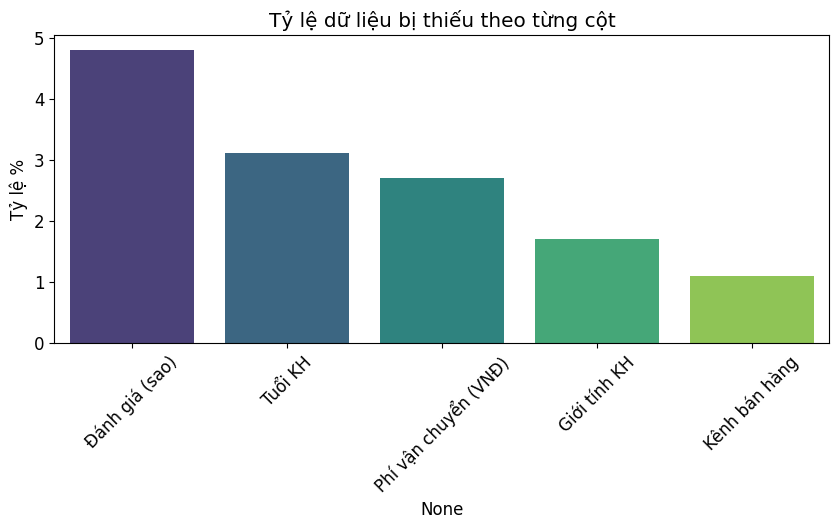

In [36]:
# Câu 4.2
# sns.barplot(x=..., y=...)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
# Lấy dữ liệu từ missing_df ở câu 4.1 (chỉ lấy những cột có missing)
data_plot = missing_df[missing_df['Số lượng Missing'] > 0]

sns.barplot(x=data_plot.index, y=data_plot['Tỷ lệ %'], palette='viridis')
plt.xticks(rotation=45)
plt.title("Tỷ lệ dữ liệu bị thiếu theo từng cột")
plt.show()

### Câu 4.3

Với cột `Tuổi KH`, hãy điền giá trị missing bằng **median**. So sánh mean và std trước và sau khi điền. Giá trị thay đổi nhiều không?

In [37]:
# Câu 4.3
# df['cột'].fillna(giá_trị, inplace=True)
# Lưu lại stats trước khi điền
mean_before = df['Tuổi KH'].mean()
std_before = df['Tuổi KH'].std()

# Thực hiện điền
median_age = df['Tuổi KH'].median()
df['Tuổi KH'].fillna(median_age, inplace=True)

print(f"Mean trước: {mean_before:.2f} -> Sau: {df['Tuổi KH'].mean():.2f}")
print(f"Std trước: {std_before:.2f} -> Sau: {df['Tuổi KH'].std():.2f}")

Mean trước: 34.66 -> Sau: 34.66
Std trước: 9.35 -> Sau: 9.35


### Câu 4.4

Với cột `Đánh giá (sao)`, hãy điền missing bằng **mode** (giá trị xuất hiện nhiều nhất). Giải thích tại sao mode phù hợp hơn mean cho biến này?

In [38]:
# Câu 4.4
mode_eval = df['Đánh giá (sao)'].mode()[0]
df['Đánh giá (sao)'].fillna(mode_eval, inplace=True)

print(f"Giá trị Mode dùng để điền: {mode_eval}")

Giá trị Mode dùng để điền: 5.0


### Câu 4.5

Với cột `Phí vận chuyển (VNĐ)`, hãy điền missing bằng **mean theo nhóm `Khu vực`** (mỗi khu vực có mean khác nhau). Tại sao cách này tốt hơn điền mean chung?

In [53]:
# # Câu 4.5
# df.groupby('nhóm')['cột'].transform('mean')
df['Phí vận chuyển (VNĐ)'] = df['Phí vận chuyển (VNĐ)'].fillna(
    df.groupby('Khu vực')['Phí vận chuyển (VNĐ)'].transform('mean')
)

### Câu 4.6

Với cột `Giới tính KH`, hãy điền missing bằng phương pháp **random sampling** (lấy ngẫu nhiên từ các giá trị không missing, giữ nguyên tỷ lệ Nam/Nữ). Kiểm tra tỷ lệ Nam/Nữ trước và sau.

In [55]:
# Câu 4.6
# Câu 4.6 (Thêm dòng cuối để xem kết quả)
def fill_random(series):
    non_null = series.dropna()
    return series.apply(lambda x: np.random.choice(non_null) if pd.isnull(x) else x)

df['Giới tính KH'] = fill_random(df['Giới tính KH'])

# --- Thêm dòng này để kiểm tra ---
print("Số lượng giá trị thiếu còn lại ở cột Giới tính:", df['Giới tính KH'].isnull().sum())
df['Giới tính KH'].head(5)

Số lượng giá trị thiếu còn lại ở cột Giới tính: 0


0     Nữ
1    Nam
2    Nam
3     Nữ
4    Nam
Name: Giới tính KH, dtype: str

### Câu 4.7

Với cột `Kênh bán hàng` (chỉ ~1% missing), hãy **loại bỏ (drop)** các dòng có missing. So sánh kích thước DataFrame trước và sau. Khi nào nên drop thay vì điền?

In [56]:
# Câu 4.7
# df.dropna(subset=['tên_cột'], inplace=True)
print(f"Kích thước trước khi drop: {df.shape}")
df.dropna(subset=['Kênh bán hàng'], inplace=True)
print(f"Kích thước sau khi drop: {df.shape}")

Kích thước trước khi drop: (999, 21)
Kích thước sau khi drop: (988, 21)


### Câu 4.8

Tạo cột mới `Flag_Missing` đánh dấu 1 nếu dòng đó có **bất kỳ cột nào bị missing**, 0 nếu không. Tính tỷ lệ dòng có missing. So sánh doanh thu TB giữa nhóm có và không có missing.

In [57]:
# Câu 4.8
df['Flag_Missing'] = df.isnull().any(axis=1).astype(int)

# So sánh doanh thu TB
print(df.groupby('Flag_Missing')['Thành tiền (VNĐ)'].mean())


Flag_Missing
0    6.259617e+06
1    2.836554e+06
Name: Thành tiền (VNĐ), dtype: float64


### Câu 4.9

Kiểm tra xem missing có phải **MCAR (Missing Completely At Random)** không: Với cột `Đánh giá (sao)`, kiểm tra xem tỷ lệ missing có khác biệt đáng kể giữa các nhóm `Trạng thái` không. Tính tỷ lệ missing theo từng trạng thái và nhận xét.

In [58]:
# Câu 4.9

# Tính tỷ lệ missing của cột Đánh giá theo từng Trạng thái
missing_by_status = df.groupby('Trạng thái')['Đánh giá (sao)'].apply(lambda x: x.isnull().mean())
print(missing_by_status)

Trạng thái
Hoàn thành    0.047749
Trả hàng      0.092308
Đang giao     0.018182
Đã hủy        0.037500
Name: Đánh giá (sao), dtype: float64


### Câu 4.10

Tạo một bản sao của DataFrame. Thực hiện **3 chiến lược** xử lý missing khác nhau: 
(A) Drop tất cả dòng có missing, 
(B) Điền tất cả bằng median/mode, 
(C) Điền theo nhóm. So sánh: kích thước, mean Thành tiền, std Thành tiền của 3 phương án. 

Phương án nào bạn khuyến nghị?

In [59]:
# Câu 4.10

# Tạo 3 bản sao
df_a = df.copy().dropna() # Chiến lược A
# ... thực hiện B và C tương tự các câu trên

# Lập bảng so sánh
results = pd.DataFrame({
    'Phương án': ['Gốc', 'Drop All', 'Fill Median/Mode', 'Fill Group'],
    'Số dòng': [len(df), len(df_a), ...],
    'Mean Thành tiền': [df['Thành tiền (VNĐ)'].mean(), df_a['Thành tiền (VNĐ)'].mean(), ...]
})
display(results)

ValueError: All arrays must be of the same length

---
# CHỦ ĐỀ 5: GOM NHÓM, TỔNG HỢP DỮ LIỆU, PIVOT TABLE
---

### Câu 5.1

Dùng `groupby` tính **số đơn hàng** và **tổng `Thành tiền (VNĐ)`** theo từng `Khu vực`. Sắp xếp theo tổng doanh thu giảm dần.

In [60]:
# Câu 5.1
# df.groupby('cột_gom_nhóm')['cột_tính_toán'].agg(['hàm1', 'hàm2'])
# Gom nhóm theo Khu vực, tính số đơn (count) và tổng tiền (sum)
region_stats = df.groupby('Khu vực')['Thành tiền (VNĐ)'].agg(['count', 'sum'])

# Đổi tên cột cho dễ hiểu và sắp xếp giảm dần theo tổng tiền
region_stats.columns = ['Số đơn hàng', 'Tổng doanh thu']
region_stats = region_stats.sort_values(by='Tổng doanh thu', ascending=False)

display(region_stats)


,Số đơn hàng,Tổng doanh thu
Khu vực,,
Miền Nam,390,2.581821e+09
Miền Bắc,318,2.487279e+09
Miền Trung,182,5.518030e+08
Tây Nguyên,98,3.102920e+08


### Câu 5.2

Tính **doanh thu trung bình, trung vị, độ lệch chuẩn** của `Thành tiền (VNĐ)` theo từng `Nhóm sản phẩm`. Nhóm nào có doanh thu trung bình cao nhất? Nhóm nào ổn định nhất (std thấp nhất)?

In [61]:
# Câu 5.2
prod_stats = df.groupby('Nhóm sản phẩm')['Thành tiền (VNĐ)'].agg(['mean', 'median', 'std'])

# Tìm nhóm có doanh thu TB cao nhất và nhóm ổn định nhất (std thấp nhất)
max_mean = prod_stats['mean'].idxmax()
min_std = prod_stats['std'].idxmin()

print(f"Nhóm có doanh thu TB cao nhất: {max_mean}")
print(f"Nhóm kinh doanh ổn định nhất (biến động thấp): {min_std}")
display(prod_stats)



Nhóm có doanh thu TB cao nhất: Điện tử
Nhóm kinh doanh ổn định nhất (biến động thấp): Văn phòng phẩm


,mean,median,std
Nhóm sản phẩm,,,
Gia dụng,5.059149e+06,2133000.0,2.011448e+07
Mỹ phẩm,1.838803e+06,591000.0,6.340201e+06
Thời trang,2.067781e+06,1016500.0,5.929129e+06
Thực phẩm,3.509042e+05,174500.0,1.068789e+06
Văn phòng phẩm,1.191954e+05,51000.0,3.163510e+05
Điện tử,2.156856e+07,6911500.0,8.766182e+07


### Câu 5.3

Tính **đánh giá trung bình** theo từng `Kênh bán hàng`. Kênh nào được đánh giá cao nhất?

In [63]:
# Câu 5.3
# df.groupby('tên_cột_phân_loại')['tên_cột_giá_trị'].mean()
# 1. Tính trung bình cộng cột 'Đánh giá (sao)' gom nhóm theo 'Kênh bán hàng'
channel_rating = df.groupby('Kênh bán hàng')['Đánh giá (sao)'].mean()

# 2. Sắp xếp kết quả từ cao xuống thấp để dễ quan sát
channel_rating = channel_rating.sort_values(ascending=False)

# 3. Tìm kênh có điểm cao nhất
best_channel = channel_rating.idxmax()
best_score = channel_rating.max()

print("Đánh giá trung bình theo từng kênh bán hàng:")
print(channel_rating)
print(f"\n=> Kênh được đánh giá cao nhất là: {best_channel} với {best_score:.2f} sao.")

Đánh giá trung bình theo từng kênh bán hàng:
Kênh bán hàng
Đại lý      4.112554
Online      4.049587
Siêu thị    4.008197
Cửa hàng    4.000000
Name: Đánh giá (sao), dtype: float64

=> Kênh được đánh giá cao nhất là: Đại lý với 4.11 sao.


### Câu 5.4

Gom nhóm theo **tháng** (từ `Ngày đặt hàng`), tính **tổng doanh thu** và **số đơn hàng** theo từng tháng. Tháng nào có doanh thu cao nhất?

In [62]:
# Câu 5.4
# Tạo cột Tháng từ cột Ngày đặt hàng
df['Tháng'] = df['Ngày đặt hàng'].dt.to_period('M')

monthly_stats = df.groupby('Tháng')['Thành tiền (VNĐ)'].agg(['sum', 'count'])
display(monthly_stats.sort_index())


,sum,count
Tháng,,
2023-01,2.068730e+08,38
2023-02,1.042920e+08,32
2023-03,2.146370e+08,51
2023-04,9.235800e+07,42
2023-05,2.261420e+08,30
2023-06,2.227080e+08,40
2023-07,1.264460e+08,34
2023-08,1.777586e+09,53
2023-09,1.531950e+08,54


### Câu 5.5

Tạo **Pivot Table**: dòng = `Khu vực`, cột = `Nhóm sản phẩm`, giá trị = tổng `Thành tiền (VNĐ)`. Thêm tổng dòng và tổng cột.

In [64]:
# Câu 5.5
# pd.pivot_table(df, values='...', index='...', columns='...', aggfunc='sum', margins=True)
pivot_revenue = pd.pivot_table(df, 
                               values='Thành tiền (VNĐ)', 
                               index='Khu vực', 
                               columns='Nhóm sản phẩm', 
                               aggfunc='sum', 
                               margins=True, # Tạo dòng/cột Tổng cộng
                               margins_name='Tổng cộng')

display(pivot_revenue)

Nhóm sản phẩm,Gia dụng,Mỹ phẩm,Thời trang,Thực phẩm,Văn phòng phẩm,Điện tử,Tổng cộng
Khu vực,,,,,,,
Miền Bắc,142222000.0,96141000.0,120911000.0,34965000.0,1404000.0,2.091636e+09,2.487279e+09
Miền Nam,494792000.0,54905000.0,165624000.0,33713000.0,5510000.0,1.827277e+09,2.581821e+09
Miền Trung,62289000.0,64981000.0,55143000.0,11785000.0,2960000.0,3.546450e+08,5.518030e+08
Tây Nguyên,49451000.0,17501000.0,26387000.0,3754000.0,496000.0,2.127030e+08,3.102920e+08
Tổng cộng,748754000.0,233528000.0,368065000.0,84217000.0,10370000.0,4.486261e+09,5.931195e+09


### Câu 5.6

Tạo **Pivot Table**: dòng = `Phương thức thanh toán`, cột = `Trạng thái`, giá trị = **đếm** số đơn hàng. Phương thức nào có tỷ lệ hủy cao nhất?

In [65]:
# Câu 5.6
pivot_status = pd.pivot_table(df, 
                              index='Phương thức thanh toán', 
                              columns='Trạng thái', 
                              aggfunc='size', # Tương đương với count
                              fill_value=0)

# Tính tỷ lệ hủy = (Số đơn Đã hủy / Tổng số đơn của phương thức đó) * 100
pivot_status['Tỷ lệ hủy (%)'] = (pivot_status['Đã hủy'] / pivot_status.sum(axis=1)) * 100
display(pivot_status.sort_values('Tỷ lệ hủy (%)', ascending=False))


Trạng thái,Hoàn thành,Trả hàng,Đang giao,Đã hủy,Tỷ lệ hủy (%)
Phương thức thanh toán,,,,,
Thẻ tín dụng,128,7,24,20,11.173184
Chuyển khoản,203,21,32,24,8.571429
Ví điện tử,144,20,23,14,6.965174
COD,74,7,14,7,6.862745
Tiền mặt,184,10,17,15,6.637168


### Câu 5.7

Gom nhóm theo **Khu vực × Kênh bán hàng** (2 cấp). Tính tổng doanh thu và đếm số đơn. Sự kết hợp nào mang lại doanh thu cao nhất?

In [69]:
# Câu 5.7
# df.groupby(['Cột_1', 'Cột_2'])['Cột_giá_trị'].agg(['hàm_1', 'hàm_2'])
# 1. Gom nhóm 2 cấp: Khu vực và Kênh bán hàng
# Sử dụng cột 'Thành tiền (VNĐ)' để tính tổng doanh thu và đếm số đơn
combined_stats = df.groupby(['Khu vực', 'Kênh bán hàng'])['Thành tiền (VNĐ)'].agg(['sum', 'count'])

# 2. Đổi tên cột để bảng báo cáo chuyên nghiệp hơn
combined_stats.columns = ['Tổng doanh thu', 'Số đơn hàng']

# 3. Sắp xếp để dễ quan sát sự kết hợp hiệu quả nhất
combined_stats = combined_stats.sort_values(by='Tổng doanh thu', ascending=False)

# 4. Tìm sự kết hợp mang lại doanh thu cao nhất
best_combo = combined_stats['Tổng doanh thu'].idxmax()
max_revenue = combined_stats['Tổng doanh thu'].max()

print("Thống kê chi tiết theo Khu vực và Kênh bán hàng:")
display(combined_stats)

print(f"\n=> Sự kết hợp mang lại doanh thu cao nhất là: {best_combo} với {max_revenue:,.0f} VNĐ.")

Thống kê chi tiết theo Khu vực và Kênh bán hàng:


Tổng doanh thu  Số đơn hàng
Khu vực    Kênh bán hàng                             
Miền Bắc   Cửa hàng         1.458012e+09           63
Miền Nam   Cửa hàng         9.089220e+08           98
           Online           7.968700e+08          102
           Đại lý           4.674290e+08           91
Miền Bắc   Đại lý           4.286210e+08           87
           Siêu thị         4.154340e+08           87
Miền Nam   Siêu thị         4.086000e+08           99
Miền Trung Cửa hàng         1.906030e+08           55
Miền Bắc   Online           1.852120e+08           81
Miền Trung Online           1.248520e+08           44
           Siêu thị         1.237040e+08           46
           Đại lý           1.126440e+08           37
Tây Nguyên Đại lý           1.027800e+08           32
           Siêu thị         9.478600e+07           27
           Online           8.882100e+07           23
           Cửa hàng         2.390500e+07           16


=> Sự kết hợp mang lại doanh thu cao nhất là: ('Miền Bắc', 'Cửa hàng') với 1,458,012,000 VNĐ.


### Câu 5.8

Tạo cột `Nhóm tuổi`: 18–25, 26–35, 36–45, 46–55, 56+. Tính **doanh thu trung bình** và **sản phẩm mua nhiều nhất** theo từng nhóm tuổi.

In [66]:
# Câu 5.8

# Chia nhóm tuổi bằng hàm pd.cut
bins = [18, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['Nhóm tuổi'] = pd.cut(df['Tuổi KH'], bins=bins, labels=labels)

# Tính doanh thu TB và Sản phẩm mua nhiều nhất
age_analysis = df.groupby('Nhóm tuổi').agg({
    'Thành tiền (VNĐ)': 'mean',
    'Nhóm sản phẩm': lambda x: x.mode()[0] # Tìm mode (sp mua nhiều nhất)
})
display(age_analysis)

,Thành tiền (VNĐ),Nhóm sản phẩm
Nhóm tuổi,,
18-25,1.305617e+07,Thực phẩm
26-35,5.889412e+06,Thực phẩm
36-45,4.257212e+06,Điện tử
46-55,5.004025e+06,Điện tử
56+,2.555857e+06,Thời trang


### Câu 5.9

Phân tích **RFM đơn giản** cho mỗi `Mã nhân viên`: (R) Ngày bán hàng gần nhất, (F) Tổng số đơn, (M) Tổng doanh thu. 

Xếp hạng top 10 nhân viên theo từng tiêu chí.

Ghi chú: Có thể đọc thêm về phân tích RFM

In [67]:
# Câu 5.9

# Tính R (Recency), F (Frequency), M (Monetary)
rfm_staff = df.groupby('Mã nhân viên').agg({
    'Ngày đặt hàng': lambda x: (df['Ngày đặt hàng'].max() - x.max()).days, # Số ngày từ lần bán cuối
    'Mã đơn hàng': 'count', # Tổng số đơn
    'Thành tiền (VNĐ)': 'sum' # Tổng doanh thu
})

rfm_staff.columns = ['Recency', 'Frequency', 'Monetary']
display(rfm_staff.nlargest(10, 'Monetary')) # Top 10 nhân viên doanh thu cao nhất

,Recency,Frequency,Monetary
Mã nhân viên,,,
NV046,11,20,1.196989e+09
NV033,17,24,5.224570e+08
NV047,8,22,2.880880e+08
NV006,5,21,2.384670e+08
NV035,9,21,2.364940e+08
NV005,11,31,2.182250e+08
NV013,22,24,2.179190e+08
NV015,0,19,1.744530e+08
NV048,116,20,1.583820e+08


### Câu 5.10

Tạo **Pivot Table lồng ghép** (multi-index): dòng = (`Khu vực`, `Nhóm sản phẩm`), cột = `Quý` (Q1–Q4 của 2024), giá trị = tổng `Thành tiền (VNĐ)`. Tính thêm tăng trưởng % giữa các quý cho mỗi (Khu vực × Nhóm SP).

In [68]:
# Câu 5.10

# Lọc dữ liệu năm 2024
df_2024 = df[df['Ngày đặt hàng'].dt.year == 2024].copy()
df_2024['Quý'] = df_2024['Ngày đặt hàng'].dt.quarter

# Tạo Pivot Table đa cấp
quarterly_pivot = pd.pivot_table(df_2024, 
                                 values='Thành tiền (VNĐ)', 
                                 index=['Khu vực', 'Nhóm sản phẩm'], 
                                 columns='Quý', 
                                 aggfunc='sum')

# Tính % tăng trưởng (Công thức: (Q2-Q1)/Q1 * 100)
# Dùng hàm .pct_change(axis=1) để tính nhanh tỷ lệ thay đổi giữa các cột
growth = quarterly_pivot.pct_change(axis=1) * 100

display(quarterly_pivot)
print("Bảng tăng trưởng % giữa các quý:")
display(growth)

Quý                                  1            2            3            4
Khu vực    Nhóm sản phẩm                                                     
Miền Bắc   Gia dụng         14372000.0   13099000.0   28751000.0   17160000.0
           Mỹ phẩm          12754000.0   56240000.0    8186000.0     739000.0
           Thời trang       13564000.0    3872000.0   18019000.0   10521000.0
           Thực phẩm         1685000.0    1957000.0    2516000.0    5662000.0
           Văn phòng phẩm      67000.0     144000.0     187000.0     231000.0
           Điện tử         121836000.0   97368000.0  264230000.0   98950000.0
Miền Nam   Gia dụng         31112000.0   36263000.0   18762000.0   11537000.0
           Mỹ phẩm          11840000.0    2122000.0    7725000.0    6206000.0
           Thời trang        8035000.0    4310000.0    7324000.0   85947000.0
           Thực phẩm        13369000.0    2576000.0    2615000.0    2663000.0
           Văn phòng phẩm    2298000.0     211000.0    1512000.0     334000.0
           Điện tử         150850000.0  148315000.0  185440000.0  191924000.0
Miền Trung Gia dụng          4622000.0    7953000.0   21951000.0    4021000.0
           Mỹ phẩm          45609000.0    7115000.0     510000.0    5525000.0
           Thời trang        1914000.0    8928000.0   19639000.0    3890000.0
           Thực phẩm         2216000.0    1455000.0    1274000.0    2180000.0
           Văn phòng phẩm      54000.0          NaN     151000.0     248000.0
           Điện tử           8154000.0   10456000.0   55976000.0   38402000.0
Tây Nguyên Gia dụng                NaN    6023000.0    9394000.0    9356000.0
           Mỹ phẩm           6853000.0    1412000.0    1029000.0     165000.0
           Thời trang         408000.0   13993000.0    1366000.0      62000.0
           Thực phẩm          593000.0     507000.0     457000.0     272000.0
           Văn phòng phẩm      19000.0     176000.0      38000.0      21000.0
           Điện tử          17071000.0   15708000.0   24842000.0   15982000.0

Bảng tăng trưởng % giữa các quý:


Quý                         1            2           3            4
Khu vực    Nhóm sản phẩm                                           
Miền Bắc   Gia dụng       NaN    -8.857501  119.490037   -40.315119
           Mỹ phẩm        NaN   340.959699  -85.444523   -90.972392
           Thời trang     NaN   -71.453848  365.366736   -41.611632
           Thực phẩm      NaN    16.142433   28.564129   125.039746
           Văn phòng phẩm NaN   114.925373   29.861111    23.529412
           Điện tử        NaN   -20.082734  171.372525   -62.551565
Miền Nam   Gia dụng       NaN    16.556313  -48.261313   -38.508688
           Mỹ phẩm        NaN   -82.077703  264.043355   -19.663430
           Thời trang     NaN   -46.359676   69.930394  1073.498088
           Thực phẩm      NaN   -80.731543    1.513975     1.835564
           Văn phòng phẩm NaN   -90.818103  616.587678   -77.910053
           Điện tử        NaN    -1.680477   25.031184     3.496549
Miền Trung Gia dụng       NaN    72.068369  176.009053   -81.681928
           Mỹ phẩm        NaN   -84.400009  -92.832045   983.333333
           Thời trang     NaN   366.457680  119.970878   -80.192474
           Thực phẩm      NaN   -34.341155  -12.439863    71.114600
           Văn phòng phẩm NaN          NaN         NaN    64.238411
           Điện tử        NaN    28.231543  435.348125   -31.395598
Tây Nguyên Gia dụng       NaN          NaN   55.968786    -0.404514
           Mỹ phẩm        NaN   -79.395885  -27.124646   -83.965015
           Thời trang     NaN  3329.656863  -90.237976   -95.461201
           Thực phẩm      NaN   -14.502530   -9.861933   -40.481400
           Văn phòng phẩm NaN   826.315789  -78.409091   -44.736842
           Điện tử        NaN    -7.984301   58.148714   -35.665405

---
# CHỦ ĐỀ 6: TRỰC QUAN HÓA DỮ LIỆU

### Câu 6.1

Vẽ **bar chart** thể hiện số đơn hàng theo từng `Khu vực`. Sắp xếp giảm dần. Ghi giá trị lên mỗi cột.

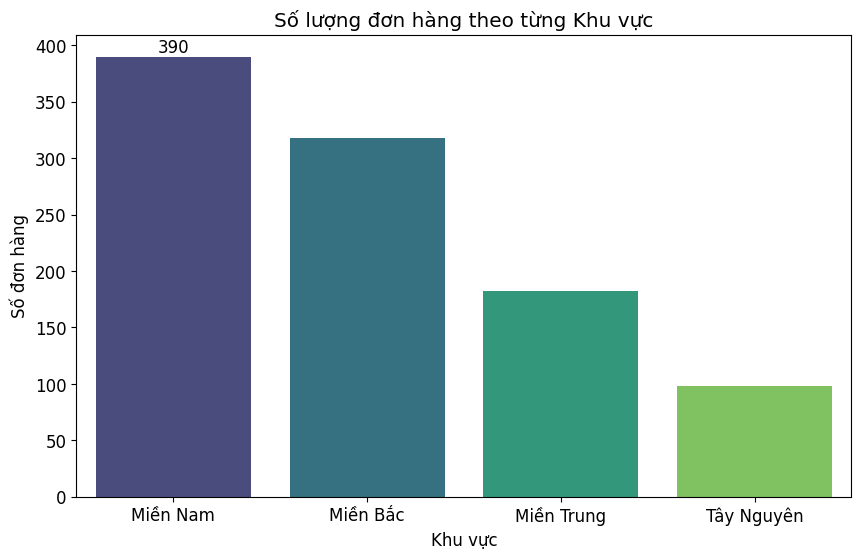

In [70]:
# Câu 6.1
# sns.countplot(data=df, x='Cột', order=...)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Tính toán thứ tự giảm dần
order = df['Khu vực'].value_counts().index

ax = sns.countplot(data=df, x='Khu vực', order=order, palette='viridis')

# Ghi giá trị lên đầu mỗi cột
ax.bar_label(ax.containers[0])

plt.title("Số lượng đơn hàng theo từng Khu vực")
plt.xlabel("Khu vực")
plt.ylabel("Số đơn hàng")
plt.show()

### Câu 6.2

Vẽ **pie chart** thể hiện tỷ lệ doanh thu theo `Nhóm sản phẩm`. Hiển thị phần trăm trên mỗi phần.

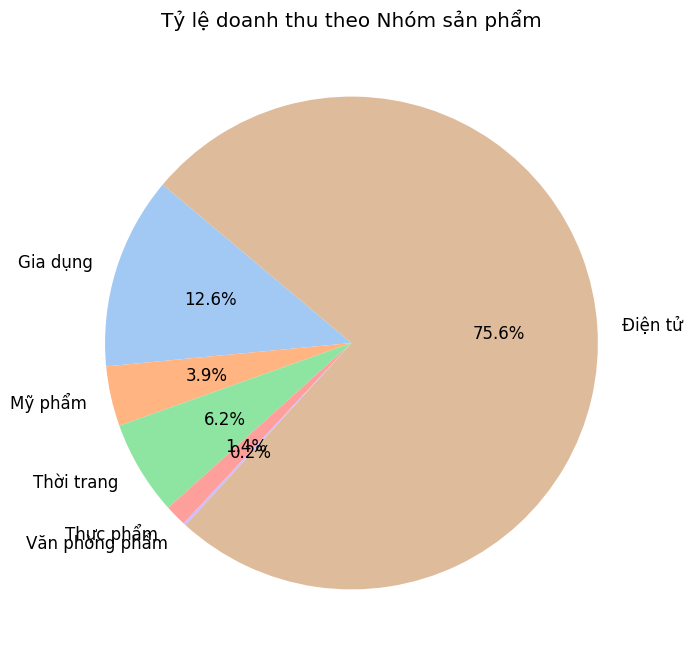

In [71]:
# Câu 6.2

# plt.pie(dữ_liệu, labels=..., autopct='%1.1f%%')
# Gom nhóm doanh thu
revenue_by_prod = df.groupby('Nhóm sản phẩm')['Thành tiền (VNĐ)'].sum()

plt.figure(figsize=(8, 8))
plt.pie(revenue_by_prod, labels=revenue_by_prod.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title("Tỷ lệ doanh thu theo Nhóm sản phẩm")
plt.show()

### Câu 6.3

Vẽ **histogram** cột `Đơn giá (VNĐ)` với 30 bins. Thêm đường KDE. Nhận xét hình dạng phân phối.

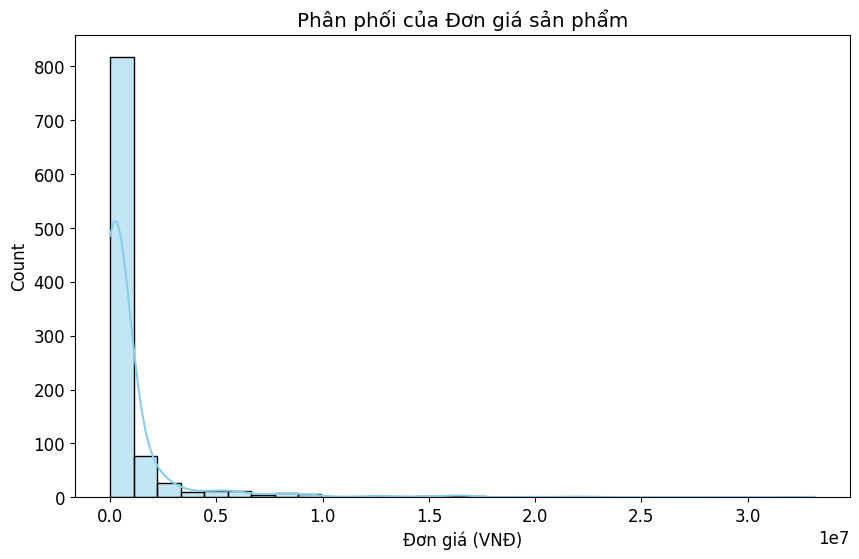

In [72]:
# Câu 6.3
# sns.histplot(df['Cột'], kde=True, bins=30)

plt.figure(figsize=(10, 6))
sns.histplot(df['Đơn giá (VNĐ)'], kde=True, bins=30, color='skyblue')

plt.title("Phân phối của Đơn giá sản phẩm")
plt.show()

### Câu 6.4

Vẽ **boxplot** so sánh `Thành tiền (VNĐ)` giữa 4 `Khu vực`. Sắp xếp theo median giảm dần. Nhận xét về outlier.

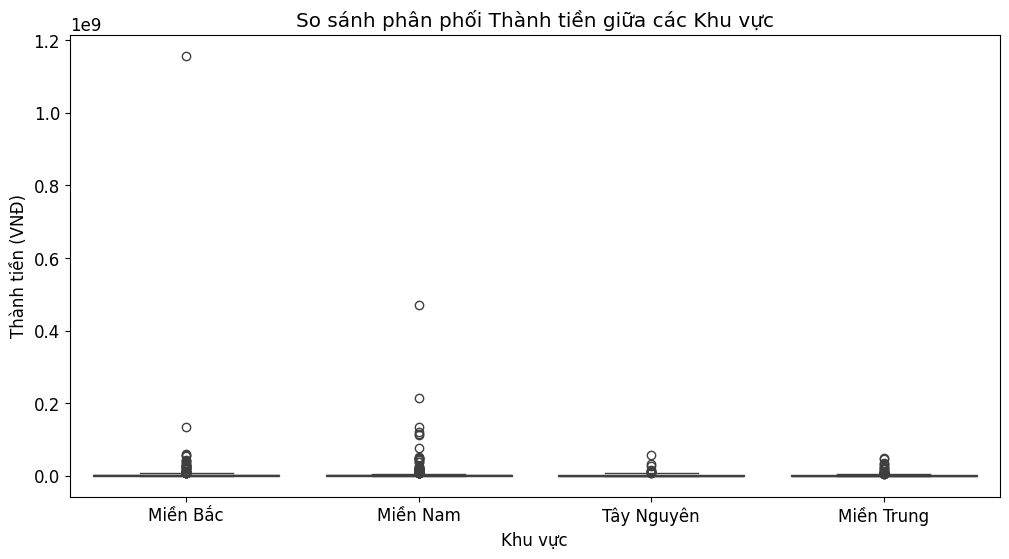

In [73]:
# Câu 6.4
# Tính median để sắp xếp
order_region = df.groupby('Khu vực')['Thành tiền (VNĐ)'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Khu vực', y='Thành tiền (VNĐ)', order=order_region)

plt.title("So sánh phân phối Thành tiền giữa các Khu vực")
plt.show()


### Câu 6.5

Vẽ **line chart** thể hiện tổng doanh thu theo tháng (2023–2024). Thêm đường trung bình (horizontal line). Nhận xét xu hướng.

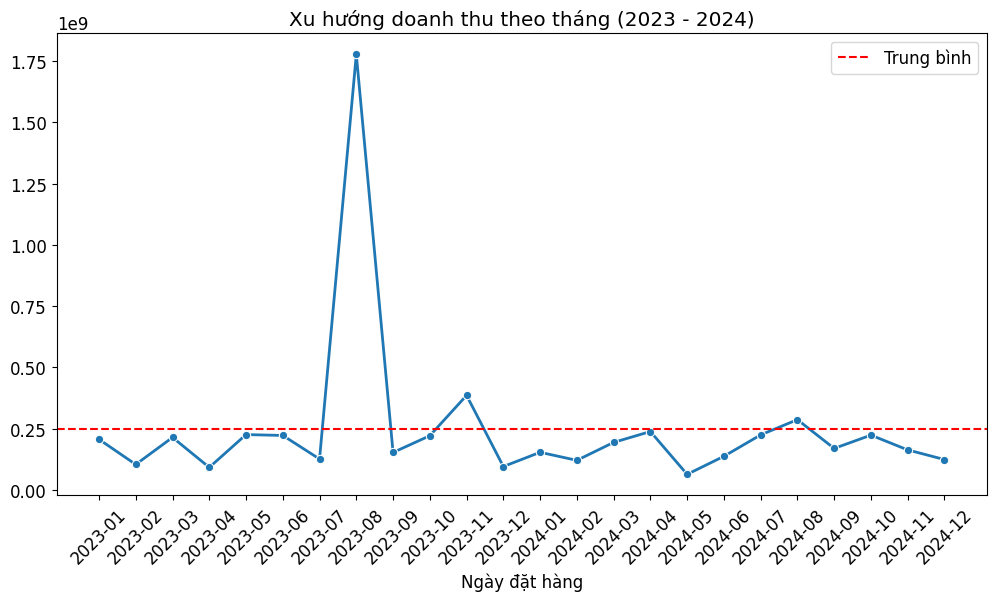

In [74]:
# Câu 6.5
# Chuyển tháng về dạng string để vẽ biểu đồ không bị lỗi định dạng
monthly_rev = df.groupby(df['Ngày đặt hàng'].dt.to_period('M'))['Thành tiền (VNĐ)'].sum()
monthly_rev.index = monthly_rev.index.astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o', linewidth=2)

# Thêm đường trung bình
plt.axhline(monthly_rev.mean(), color='red', linestyle='--', label='Trung bình')

plt.xticks(rotation=45)
plt.title("Xu hướng doanh thu theo tháng (2023 - 2024)")
plt.legend()
plt.show()


### Câu 6.6

Vẽ **countplot** thể hiện số đơn hàng theo `Phương thức thanh toán`, tô màu theo `Trạng thái` (stacked hoặc grouped).

In [ ]:
# Câu 6.6



### Câu 6.7

Vẽ **scatter plot**: trục x = `Tuổi KH`, trục y = `Thành tiền (VNĐ)`, tô màu theo `Giới tính KH`. Thêm đường hồi quy cho mỗi nhóm. Nhận xét.

In [ ]:
# Câu 6.7



### Câu 6.8

Vẽ **heatmap** ma trận tương quan giữa tất cả các biến số. Sử dụng colormap diverging (vd: `coolwarm`). Chú thích giá trị trên heatmap.

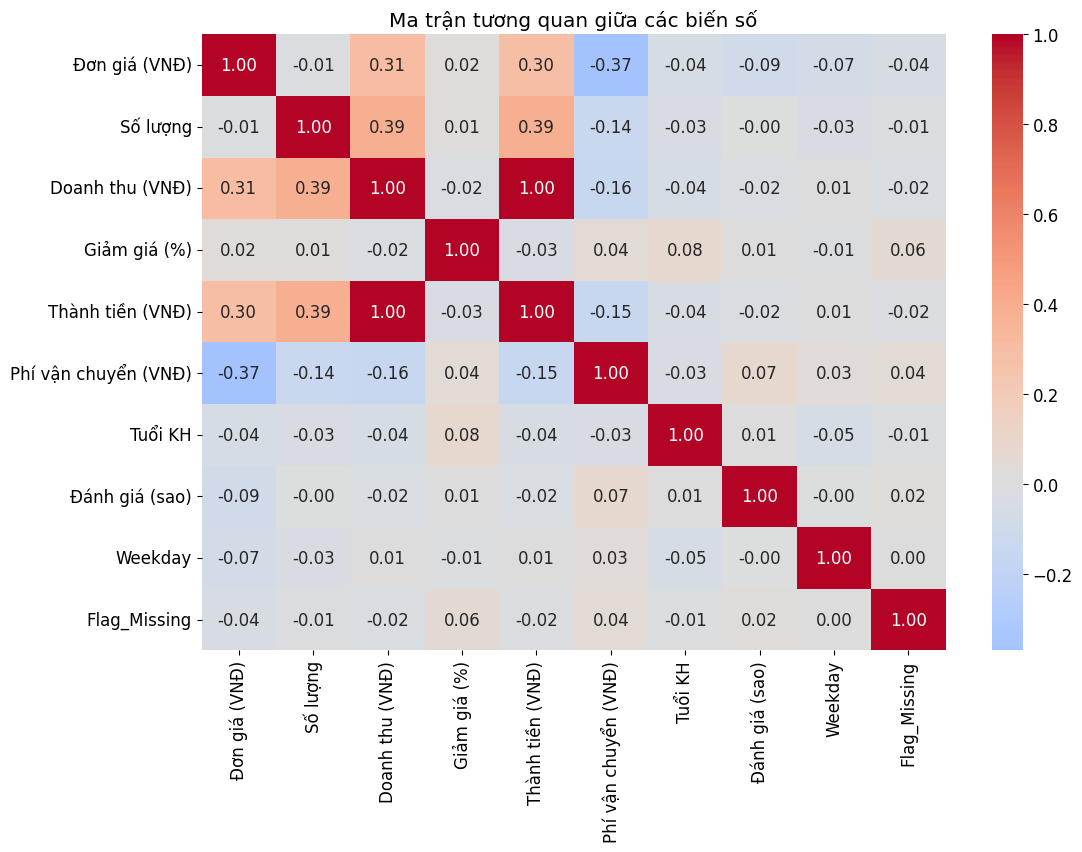

In [75]:
# Câu 6.8
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)

plt.title("Ma trận tương quan giữa các biến số")
plt.show()

### Câu 6.9

Tạo **dashboard mini** gồm 4 biểu đồ trong 1 figure (2×2 subplot): 
(1) Bar chart DT theo Khu vực, 
(2) Pie chart theo Nhóm SP, 
(3) Line chart DT theo tháng, 
(4) Boxplot Đơn giá theo Nhóm SP. 

Trình bày đẹp với tiêu đề chung.

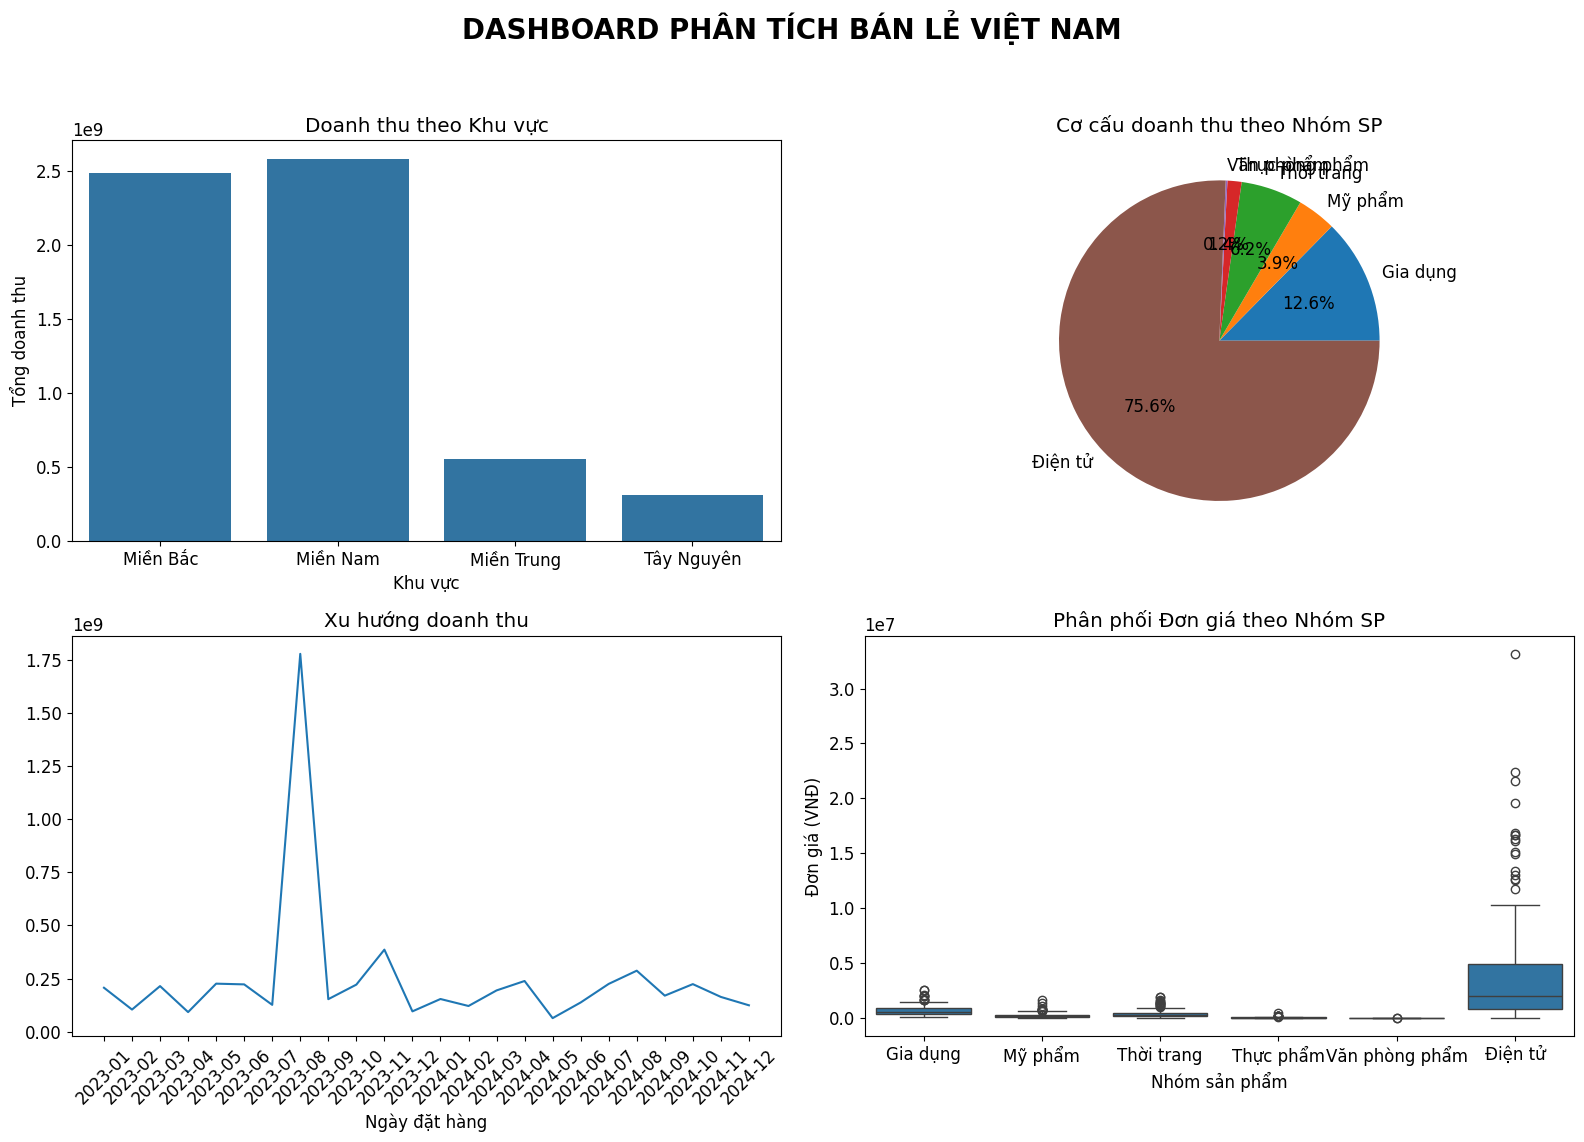

In [76]:
# Câu 6.9
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DASHBOARD PHÂN TÍCH BÁN LẺ VIỆT NAM', fontsize=20, fontweight='bold')

# (1) Bar chart
sns.barplot(ax=axes[0,0], x=region_stats.index, y=region_stats['Tổng doanh thu'])
axes[0,0].set_title("Doanh thu theo Khu vực")

# (2) Pie chart
axes[0,1].pie(revenue_by_prod, labels=revenue_by_prod.index, autopct='%1.1f%%')
axes[0,1].set_title("Cơ cấu doanh thu theo Nhóm SP")

# (3) Line chart
sns.lineplot(ax=axes[1,0], x=monthly_rev.index, y=monthly_rev.values)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title("Xu hướng doanh thu")

# (4) Boxplot
sns.boxplot(ax=axes[1,1], data=df, x='Nhóm sản phẩm', y='Đơn giá (VNĐ)')
axes[1,1].set_title("Phân phối Đơn giá theo Nhóm SP")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Câu 6.10

Vẽ **violin plot** so sánh phân phối `Tuổi KH` theo `Nhóm sản phẩm`, chia theo `Giới tính KH` (split violin). 

Thêm điểm mean. 

Nhận xét: nhóm SP nào thu hút khách trẻ nhất? Có sự khác biệt giới tính rõ rệt không?

In [ ]:
# Câu 6.10



---
# CHỦ ĐỀ 7: XÁC SUẤT, XÁC SUẤT CÓ ĐIỀU KIỆN, ĐỊNH LÝ BAYES
> **Hướng dẫn:** Sử dụng tần suất từ dữ liệu thực tế để **ước lượng xác suất** (relative frequency approach).
> - P(A) = số dòng thỏa A / tổng số dòng
> - P(A|B) = số dòng thỏa A∩B / số dòng thỏa B
---

### Câu 7.1

Tính các xác suất sau (dựa trên tần suất tương đối):
- P(Khu vực = "Miền Nam")
- P(Trạng thái = "Đã hủy")
- P(Nhóm sản phẩm = "Điện tử")
- P(Giảm giá > 0)

In [77]:
# Câu 7.1
# p_a = len(df[df['Cột'] == 'Giá trị']) / len(df)
total = len(df)

p_south = len(df[df['Khu vực'] == 'Miền Nam']) / total
p_cancelled = len(df[df['Trạng thái'] == 'Đã hủy']) / total
p_electronics = len(df[df['Nhóm sản phẩm'] == 'Điện tử']) / total
p_discount = len(df[df['Giảm giá (%)'] > 0]) / total

print(f"P(Miền Nam): {p_south:.2%}")
print(f"P(Đã hủy): {p_cancelled:.2%}")
print(f"P(Điện tử): {p_electronics:.2%}")
print(f"P(Giảm giá > 0): {p_discount:.2%}")

P(Miền Nam): 39.47%
P(Đã hủy): 8.10%
P(Điện tử): 21.05%
P(Giảm giá > 0): 35.93%


### Câu 7.2

Tính **xác suất có điều kiện**:
- P(Hoàn thành | Miền Nam) — xác suất đơn hoàn thành nếu biết đơn ở Miền Nam
- P(Hoàn thành | Tây Nguyên)
- So sánh hai xác suất này. Khu vực có ảnh hưởng đến tỷ lệ hoàn thành không?

In [78]:
# Câu 7.2
# P(A|B) = n(A ∩ B) / n(B)
# p_a_given_b = len(df[(df['A'] == 'a') & (df['B'] == 'b')]) / len(df[df['B'] == 'b'])

# P(Hoàn thành | Miền Nam)
n_south = len(df[df['Khu vực'] == 'Miền Nam'])
n_south_done = len(df[(df['Khu vực'] == 'Miền Nam') & (df['Trạng thái'] == 'Hoàn thành')])
p_done_south = n_south_done / n_south

# P(Hoàn thành | Tây Nguyên)
n_central = len(df[df['Khu vực'] == 'Tây Nguyên'])
n_central_done = len(df[(df['Khu vực'] == 'Tây Nguyên') & (df['Trạng thái'] == 'Hoàn thành')])
p_done_central = n_central_done / n_central

print(f"P(Hoàn thành | Miền Nam): {p_done_south:.2%}")
print(f"P(Hoàn thành | Tây Nguyên): {p_done_central:.2%}")


P(Hoàn thành | Miền Nam): 72.05%
P(Hoàn thành | Tây Nguyên): 79.59%


### Câu 7.3

Tính:
- P(Nữ ∩ Mỹ phẩm) — xác suất đồng thời
- P(Nữ) × P(Mỹ phẩm) — tích xác suất riêng lẻ
- So sánh hai giá trị: sự kiện "Nữ" và "mua Mỹ phẩm" có **độc lập** không?

In [79]:
# Câu 7.3
p_female = len(df[df['Giới tính KH'] == 'Nữ']) / total
p_cosmetic = len(df[df['Nhóm sản phẩm'] == 'Mỹ phẩm']) / total
p_joint = len(df[(df['Giới tính KH'] == 'Nữ') & (df['Nhóm sản phẩm'] == 'Mỹ phẩm')]) / total

p_product = p_female * p_cosmetic

print(f"P(Nữ ∩ Mỹ phẩm): {p_joint:.4f}")
print(f"P(Nữ) * P(Mỹ phẩm): {p_product:.4f}")


P(Nữ ∩ Mỹ phẩm): 0.0678
P(Nữ) * P(Mỹ phẩm): 0.0722


### Câu 7.4

Tính xác suất **hợp (union)**:
- P(Đã hủy ∪ Trả hàng) — xác suất đơn hàng bị hủy HOẶC trả hàng
- Kiểm tra: P(A ∪ B) = P(A) + P(B) − P(A ∩ B) có thỏa mãn không? (A = Đã hủy, B = Trả hàng)

In [80]:
# Câu 7.4
p_cancel = len(df[df['Trạng thái'] == 'Đã hủy']) / total
p_return = len(df[df['Trạng thái'] == 'Trả hàng']) / total
p_union = len(df[df['Trạng thái'].isin(['Đã hủy', 'Trả hàng'])]) / total

print(f"P(Hủy ∪ Trả): {p_union:.2%}")
print(f"P(Hủy) + P(Trả): {(p_cancel + p_return):.2%}")


P(Hủy ∪ Trả): 14.68%
P(Hủy) + P(Trả): 14.68%


### Câu 7.5

Một đơn hàng được chọn ngẫu nhiên. Tính:
- P(Thành tiền > 1 triệu)
- P(Thành tiền > 5 triệu)
- P(Thành tiền > 5 triệu | Nhóm SP = "Điện tử")
- Nhận xét: biết nhóm SP là Điện tử làm thay đổi xác suất như thế nào?

In [81]:
# Câu 7.5
p_gt_5m = len(df[df['Thành tiền (VNĐ)'] > 5000000]) / total
p_gt_5m_elec = len(df[(df['Thành tiền (VNĐ)'] > 5000000) & (df['Nhóm sản phẩm'] == 'Điện tử')]) / \
               len(df[df['Nhóm sản phẩm'] == 'Điện tử'])

print(f"Xác suất đơn hàng > 5tr chung: {p_gt_5m:.2%}")
print(f"Xác suất đơn hàng > 5tr nếu là Điện tử: {p_gt_5m_elec:.2%}")


Xác suất đơn hàng > 5tr chung: 15.79%
Xác suất đơn hàng > 5tr nếu là Điện tử: 55.29%


### Câu 7.6

Tính xác suất có điều kiện theo **kênh bán hàng**:
- P(Đánh giá ≥ 4 sao | Online)
- P(Đánh giá ≥ 4 sao | Cửa hàng)
- P(Đánh giá ≥ 4 sao | Đại lý)
- Kênh nào có xác suất khách hàng hài lòng cao nhất?

In [ ]:
# Câu 7.6



### Câu 7.7

Tính:
- P(Nam | Điện tử) — xác suất KH là nam biết mua Điện tử
- P(Nam | Mỹ phẩm) — xác suất KH là nam biết mua Mỹ phẩm
- P(Điện tử | Nam) — xác suất mua Điện tử biết KH là nam
- Giải thích sự khác biệt giữa P(A|B) và P(B|A).

In [82]:
# Câu 7.7

# P(Nam | Điện tử)
p_male_elec = len(df[(df['Giới tính KH'] == 'Nam') & (df['Nhóm sản phẩm'] == 'Điện tử')]) / len(df[df['Nhóm sản phẩm'] == 'Điện tử'])
# P(Điện tử | Nam)
p_elec_male = len(df[(df['Giới tính KH'] == 'Nam') & (df['Nhóm sản phẩm'] == 'Điện tử')]) / len(df[df['Giới tính KH'] == 'Nam'])

print(f"P(Nam | Điện tử): {p_male_elec:.2%}")
print(f"P(Điện tử | Nam): {p_elec_male:.2%}")

P(Nam | Điện tử): 40.38%
P(Điện tử | Nam): 19.40%


### Câu 7.8

**Ứng dụng phép cộng xác suất:**
Chọn ngẫu nhiên 1 đơn hàng. Tính xác suất đơn hàng đó:
- Thuộc Miền Nam **VÀ** mua Điện tử **VÀ** thanh toán bằng Ví điện tử
- Thuộc Miền Nam **HOẶC** mua Điện tử (dùng công thức P(A∪B))

In [ ]:
# Câu 7.8



### Câu 7.9

Định lý Bayes — Bài toán chẩn đoán:**

Biết rằng:
- Đơn hàng bị hủy (H) chiếm tỷ lệ P(H) trong dữ liệu
- Xác suất khách hàng trẻ (≤25 tuổi) trong nhóm bị hủy: P(Trẻ|H)
- Xác suất khách hàng trẻ (≤25 tuổi) trong nhóm KHÔNG bị hủy: P(Trẻ|H̄)

**Hãy tính:** Nếu biết một khách hàng ≤ 25 tuổi, xác suất đơn hàng đó bị hủy là bao nhiêu?
→ Áp dụng: **P(H|Trẻ) = P(Trẻ|H) × P(H) / P(Trẻ)**

Tính P(Trẻ) bằng công thức xác suất toàn phần: P(Trẻ) = P(Trẻ|H)×P(H) + P(Trẻ|H̄)×P(H̄)

In [83]:
# Câu 7.9
# 1. Tính các xác suất thành phần
p_h = len(df[df['Trạng thái'] == 'Đã hủy']) / total # P(H)
p_not_h = 1 - p_h # P(H̄)

df_h = df[df['Trạng thái'] == 'Đã hủy']
df_not_h = df[df['Trạng thái'] != 'Đã hủy']

p_young_h = len(df_h[df_h['Tuổi KH'] <= 25]) / len(df_h) # P(Trẻ|H)
p_young_not_h = len(df_not_h[df_not_h['Tuổi KH'] <= 25]) / len(df_not_h) # P(Trẻ|H̄)

# 2. Xác suất toàn phần P(Trẻ)
p_young = (p_young_h * p_h) + (p_young_not_h * p_not_h)

# 3. Định lý Bayes
p_h_young = (p_young_h * p_h) / p_young

print(f"Nếu biết khách hàng <= 25 tuổi, xác suất đơn hàng bị hủy là: {p_h_young:.2%}")


Nếu biết khách hàng <= 25 tuổi, xác suất đơn hàng bị hủy là: 7.88%


### Câu 7.10

Định lý Bayes — Bài toán phân loại kênh bán hàng:**

Một đơn hàng vừa được ghi nhận có: `Nhóm sản phẩm = "Điện tử"` và `Trạng thái = "Hoàn thành"`.

Sử dụng Naive Bayes đơn giản, hãy tính xác suất đơn hàng này thuộc **từng kênh bán hàng** (Cửa hàng, Online, Đại lý, Siêu thị):

P(Kênh = k | Điện tử ∩ Hoàn thành) ∝ P(Điện tử | k) × P(Hoàn thành | k) × P(k)

Tính posterior cho mỗi kênh, chuẩn hóa để tổng = 1. Kênh nào có xác suất cao nhất?

In [84]:
# Câu 7.10

channels = df['Kênh bán hàng'].unique()
posteriors = {}

# Điều kiện: Điện tử (E) và Hoàn thành (C)
for k in channels:
    df_k = df[df['Kênh bán hàng'] == k]
    p_k = len(df_k) / total
    p_e_k = len(df_k[df_k['Nhóm sản phẩm'] == 'Điện tử']) / len(df_k)
    p_c_k = len(df_k[df_k['Trạng thái'] == 'Hoàn thành']) / len(df_k)
    
    # Tính Posterior (chưa chuẩn hóa)
    posteriors[k] = p_e_k * p_c_k * p_k

# Chuẩn hóa để tổng bằng 1
total_post = sum(posteriors.values())
for k in posteriors:
    posteriors[k] /= total_post

print("Xác suất đơn hàng thuộc về từng kênh:")
for k, v in posteriors.items():
    print(f"- {k}: {v:.2%}")

Xác suất đơn hàng thuộc về từng kênh:
- Đại lý: 24.37%
- Siêu thị: 30.64%
- Online: 21.65%
- Cửa hàng: 23.34%


In [2]:
#  (1.5đ): Một ứng dụng theo dõi sức khỏe tinh thần nhận thấy rằng 18% sinh viên đạt
# mục tiêu ngủ đủ 8 giờ mỗi ngày. Nếu có 200 sinh viên tham gia khảo sát, tính xác
# suất có ít nhất 40 sinh viên đạt được mục tiêu ngủ đủ 8 giờ mỗi ngày
import scipy.stats as stats

# 1. Tính trực tiếp
p1 = 1 - stats.binom.cdf(39, 200, 0.18)
print(f"Xác suất tính theo Nhị thức: {p1:.4f}") # Thêm dòng này

# 2. Xấp xỉ chuẩn
mu = 200 * 0.18
sigma = (200 * 0.18 * 0.82)**0.5
z = (39.5 - mu) / sigma
p1_approx = 1 - stats.norm.cdf(z)
print(f"Xác suất xấp xỉ Chuẩn: {p1_approx:.4f}") # Thêm dòng này

Xác suất tính theo Nhị thức: 0.2560
Xác suất xấp xỉ Chuẩn: 0.2597


In [3]:
# Phân phối Poisson (Poisson Distribution)Mục đích:
# Dùng để đếm số sự kiện xảy ra trong một khoảng cố định (thời gian hoặc không gian) khi biết tỷ lệ trung bình.Các biến số:$\lambda$ (Lambda):
# Tỷ lệ trung bình (Average rate) của sự kiện xảy ra trong khoảng đó.$k$:
# Số lần sự kiện xảy ra mà bạn muốn tính xác suất.Ví dụ thực tế: Số lượng tin nhắn đến server trong 1 giây, hoặc số lỗi chính tả trên một trang sách.
import scipy.stats as stats

# Giả sử trung bình có 5 khách truy cập website mỗi phút (lambda = 5)
lam = 5

# Tính xác suất có đúng 3 khách truy cập trong phút tới P(X=3)
p_3 = stats.poisson.pmf(3, mu=lam)

# Tính xác suất có không quá 2 khách (0, 1 hoặc 2) P(X <= 2)
p_le_2 = stats.poisson.cdf(2, mu=lam)

print(f"P(X=3): {p_3:.4f}")
print(f"P(X<=2): {p_le_2:.4f}")

P(X=3): 0.1404
P(X<=2): 0.1247


In [4]:
# Phân phối Mũ (Exponential Distribution)Mục đích: Đo thời gian chờ giữa các sự kiện xảy ra liên tiếp (ngược lại với Poisson).
#     Các biến số:$\lambda$ (Lambda): Tốc độ xảy ra sự kiện (Rate parameter).scale: 
# Trong Python, scale $= 1/\lambda$ (đây chính là thời gian chờ trung bình).$x$: Khoảng thời gian mà bạn đang xét.
#     Ví dụ thực tế: Thời gian chờ cho đến khi một bóng đèn bị cháy, hoặc thời gian giữa hai khách hàng vào cửa hàng.
# Giả sử trung bình 10 phút mới có 1 xe buýt (lambda = 1/10)
# scale = 1 / (1/10) = 10
wait_time = 10 

# Xác suất phải đợi ít hơn 5 phút P(X < 5)
p_lt_5 = stats.expon.cdf(5, scale=wait_time)

# Xác suất phải đợi hơn 15 phút P(X > 15)
p_gt_15 = 1 - stats.expon.cdf(15, scale=wait_time)

print(f"P(X<5): {p_lt_5:.4f}")
print(f"P(X>15): {p_gt_15:.4f}")

P(X<5): 0.3935
P(X>15): 0.2231


In [5]:
# Phân phối Đều (Uniform Distribution)Mục đích: Dùng khi mọi kết quả trong một khoảng đều có khả năng xảy ra như nhau.
#     Các biến số:$a$ (loc): Giá trị nhỏ nhất của khoảng.$b$: Giá trị lớn nhất.scale: Độ dài của khoảng ($b - a$).
#     Ví dụ thực tế: Chọn ngẫu nhiên một số thực từ 0 đến 1, hoặc tung một con xúc xắc (đều rời rạc).
# Chọn ngẫu nhiên một số trong khoảng [10, 20]
a, b = 10, 20

# Xác suất chọn được số nhỏ hơn 12 P(X < 12)
p_lt_12 = stats.uniform.cdf(12, loc=a, scale=b-a)

print(f"P(X<12): {p_lt_12:.4f}") # Kết quả sẽ là (12-10)/(20-10) = 0.2

P(X<12): 0.2000


In [6]:
# Phân phối Bernoulli (Bernoulli Distribution)Mục đích: Đây là trường hợp đặc biệt nhất, chỉ có duy nhất 1 lần thử với 2 kết quả (Thành công/Thất bại).
#     Biến số:$p$: Xác suất thành công.Ví dụ thực tế: Tung đồng xu 1 lần, hoặc kiểm tra 1 sản phẩm xem có lỗi hay không. 
#     (Lưu ý: Nếu thử nhiều lần thì nó trở thành phân phối Nhị thức).
# Xác suất ném bóng rổ trúng rổ là 0.7
p = 0.7

# Xác suất trúng (X=1)
p_hit = stats.bernoulli.pmf(1, p)
# Xác suất trượt (X=0)
p_miss = stats.bernoulli.pmf(0, p)

print(f"Trúng: {p_hit}, Trượt: {p_miss}")

Trúng: 0.7, Trượt: 0.30000000000000004


Đếm số lần trong $n$ lần thử $\rightarrow$ Nhị thức.Đếm số lần trong 1 khoảng thời gian $\rightarrow$ Poisson.Tính thời gian giữa 2 lần $\rightarrow$ Mũ.Mọi thứ bằng nhau $\rightarrow$ Đều.Dữ liệu dạng hình chuông $\rightarrow$ Chuẩn.

In [8]:
# **Bài 01:** Một bài thi trắc nghiệm gồm 10 câu hỏi, mỗi câu có 4 phương án trả lời trong đó chỉ có một phương án đúng. Bạn hãy: 

# a. Một sinh viên không học bài làm bài bằng cách chọn ngẫu nhiên một phương án cho mỗi câu hỏi. Bạn hãy dùng hàm random để in ra số câu đúng của bạn sinh viên trong 10 lần kiểm tra.

# b. Giả sử mỗi câu đúng được 4 điểm, mỗi câu sai bị trừ 2 điểm. Tính xác suất để sinh viên này được 4 điểm

# c. Gọi X là số câu trả lời đúng. Tính E(X) và Var(X)
from scipy.stats import binom

n = 10
p = 0.25

# a. Mô phỏng số câu đúng trong 10 lần kiểm tra
# rvs: Random Variates (tạo các giá trị ngẫu nhiên)
samples = binom.rvs(n, p, size=10)
for i, val in enumerate(samples):
    print(f"Lần kiểm tra {i+1}: {val} câu đúng")

# b. Xác suất được đúng 4 câu (để được 4 điểm: 4*4 - 6*2 = 4)
# pmf: Probability Mass Function (Xác suất tại một điểm rời rạc)
prob_4 = binom.pmf(4, n, p)
print(f"\nXác suất đúng chính xác 4 câu: {prob_4:.4f}")

# c. Tính E(X) và Var(X)
# stats: Trả về các thông số thống kê (mean, variance, skew, kurtosis)
mu, var = binom.stats(n, p, moments='mv')
print(f"E(X) = {mu}")
print(f"Var(X) = {var}")

Lần kiểm tra 1: 3 câu đúng
Lần kiểm tra 2: 3 câu đúng
Lần kiểm tra 3: 2 câu đúng
Lần kiểm tra 4: 0 câu đúng
Lần kiểm tra 5: 1 câu đúng
Lần kiểm tra 6: 0 câu đúng
Lần kiểm tra 7: 2 câu đúng
Lần kiểm tra 8: 1 câu đúng
Lần kiểm tra 9: 2 câu đúng
Lần kiểm tra 10: 3 câu đúng

Xác suất đúng chính xác 4 câu: 0.1460
E(X) = 2.5
Var(X) = 1.875


In [ ]:
# **Bài 02:** Một trung tâm bưu điện nhận được 3 cuộc gọi điện thoại mỗi phút.
#     Tính xác suất để trung tâm nhận được 1 cuộc gọi, 2 cuộc gọi, 3 cuộc gọi trong vòng một phút biết số cuộc gọi trong một phút có phân phối Poisson.
from scipy.stats import poisson

lam = 3
k_values = [1, 2, 3]

# Tính P(X=k) cho từng giá trị k
# Sử dụng pmf vì số cuộc gọi là biến rời rạc
for k in k_values:
    prob = poisson.pmf(k, lam)
    print(f"P(X={k}) = {prob:.4f}")

In [9]:
# **Bài 03:** Trọng lượng (đơn vị gam) của một loại trái cây có phân phối chuẩn với µ = 500 (gam) gam và $σ^2 = 16 (gam^2)$. 
#     Trái cây thu hoạch được phân loại theo trọng lượng như sau:

# Loại 1: trên 505 gam

# Loại 2: từ 495 – 505 gam

# Loại 3: dười 495 gam

# a. Hãy tính tỷ lệ của mỗi loại.
# b. Bạn hãy mô phỏng lấy mẫu  20 trái cây trên. Bạn hãy vẽ histogram trọng lượng trái cây và tính giá trị trung bình và độ lệch chuẩn trái cây từ mẫu
# c. Bạn hãy mô phỏng lấy 100 trái cây trên. Bạn hãy vẽ histogram trọng lượng trái cây và tính giá trị trung bình và độ lệch chuẩn trái cây từ mẫu
# d. Từ hai cách lấy mẫu ở câu b, c bạn có nhận xét gì không?
from scipy.stats import norm
import numpy as np

mu = 500
sigma = 4 # Căn bậc hai của phương sai 16

# a. Tính tỷ lệ mỗi loại
# sf (Survival Function) tương đương 1 - cdf, dùng cho xác suất "lớn hơn"
p_loai1 = norm.sf(505, loc=mu, scale=sigma)

# Khoảng từ 495 đến 505
p_loai2 = norm.cdf(505, mu, sigma) - norm.cdf(495, mu, sigma)

# Dưới 495
p_loai3 = norm.cdf(495, mu, sigma)

print(f"Tỷ lệ Loại 1 (>505g): {p_loai1:.4%}")
print(f"Tỷ lệ Loại 2 (495-505g): {p_loai2:.4%}")
print(f"Tỷ lệ Loại 3 (<495g): {p_loai3:.4%}")

# b & c. Mô phỏng lấy mẫu n=20 và n=100
for n in [20, 100]:
    sample = norm.rvs(loc=mu, scale=sigma, size=n)
    print(f"\n--- Mẫu cỡ n={n} ---")
    print(f"Trung bình mẫu: {sample.mean():.2f}")
    print(f"Độ lệch chuẩn mẫu: {sample.std():.2f}")

Tỷ lệ Loại 1 (>505g): 10.5650%
Tỷ lệ Loại 2 (495-505g): 78.8700%
Tỷ lệ Loại 3 (<495g): 10.5650%

--- Mẫu cỡ n=20 ---
Trung bình mẫu: 500.29
Độ lệch chuẩn mẫu: 3.60

--- Mẫu cỡ n=100 ---
Trung bình mẫu: 500.50
Độ lệch chuẩn mẫu: 3.97


---
*Chúc các bạn ôn tập hiệu quả!*

---

CHANGELOG

- 20260324: Firt release
- ...
---